# Plots for figure 2

Read in all necessary packages:

In [22]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pandas.io.parsers import read_csv
import scvelo as scv
import scanpy as sc
import numpy as np
from functools import reduce
from anndata import AnnData, read_h5ad
#import singlecellmultiomics.bamProcessing.bamToRNACounts
import loompy
import collections

import matplotlib as mpl
mpl.rcParams['image.cmap'] = 'viridis'


In [3]:
dpi=80

In [4]:
scv.settings.verbosity = 3 # show errors(0), warnings(1), info(2), hints(3)
sc.settings.verbosity = 3  # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()

trans = sns.blend_palette(['black','#d94801', '#fd8e3d', '#fdd1a3'], as_cmap = True)
k4 = sns.blend_palette(['black','#238b45', '#75c477', '#c8e9c1' ], as_cmap = True)
k27 = sns.blend_palette(['black','#6a51a3', '#9e9bc8', '#dadaeb'], as_cmap = True)

scv.settings.presenter_view = True  # set max width size for presenter view
sc.set_figure_params(dpi=dpi, color_map = trans)



# Load the dataset + reorganise

In [5]:
#import adata file. File can be found on GEO
adata = sc.read_h5ad('input/GSE302471_TChIC_Full_Gastruloid_dataset.h5ad')
adata

AnnData object with n_obs × n_vars = 38117 × 27384
    obs: 'batch2', 'batch', 'day', 'replicates', 'mark', 'day_rep', 'dataset', 'cellnames', 'bc', 'cellname', 'percent_mito', 'n_counts', 'n_counts_proteincoding', 'n_counts_stressgenes', 'n_genes', 'S_score', 'G2M_score', 'phase', 'histone_score', 'enrichment', 'coverage', 'QC', 'leiden', 'celltype', 'celltype_general', 'lineage', 'lin_day', 'hour', 'PT1', 'PT1_avg', 'K4_total', 'K27_total', 'K4_total_log', 'K27_total_log', 'RNA_total_log'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'gene', 'gene_biotype', 'gene_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'QC_colors', 'batch_colors', 'celltype_colors', 'celltype_general_colors', 'dataset_colors', 'day_colors', 'hour_colors', 'hvg', 'leiden', 'leiden_colors', 'lin_day_colors', 'lineage_colors', 'log1p', 'mark_colors', 'neighbors', 'pca', 'phase_colors', 'replicates_colors', 'umap', 'umap_density_mark_params

In [12]:
print(adata.obs['lin_day'].dtype)

category


In [7]:
sc.get.obs_df(adata, keys = [
    'batch','day','replicates','mark', 'day_rep', 'dataset','hour',
    'celltype','celltype_general','lineage','lin_day',
    'percent_mito', 'n_counts', 'n_counts_proteincoding','n_genes',
    'S_score','G2M_score', 'phase',
    'enrichment','coverage','QC',
    'PT1'],
              obsm_keys=[("X_umap", 0), ("X_umap", 1)]).to_csv('adata_obs_celltyping.csv', sep = '\t')

In [8]:
adata.obs['mark'].value_counts()

mark
H3K27me3    19838
H3K4me3     18279
Name: count, dtype: int64

# small plots

saving figure to file figures\umapFig2f1.png


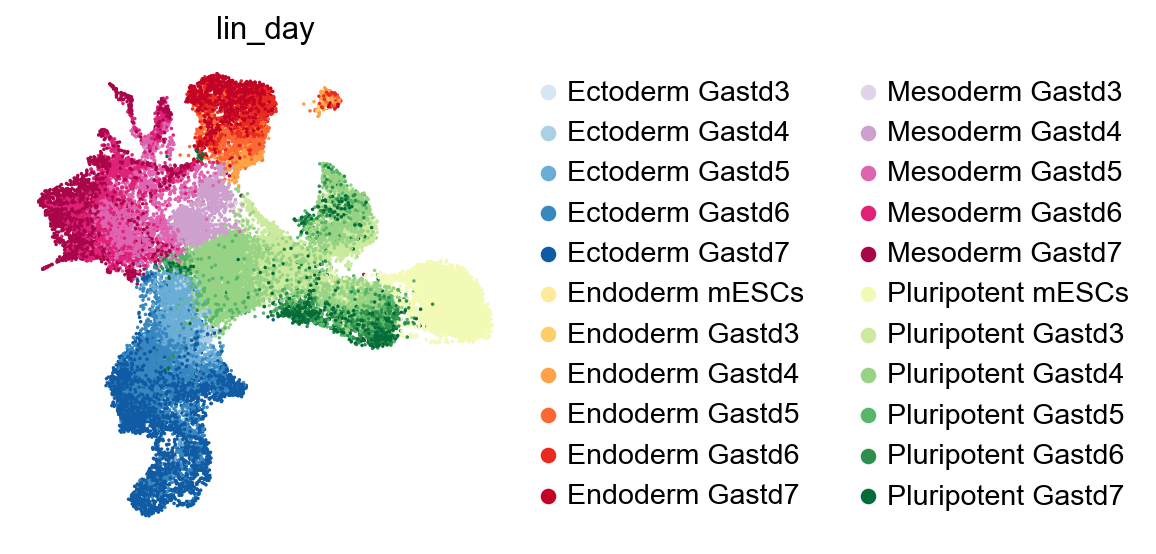

In [24]:

lin_day_palette = [
    '#d6e6f4', '#abd0e6', '#6aaed6', '#3787c0', '#105ba4',#blue
    '#ffea9b', '#fece6a', '#fea245', '#fc6832', '#ea2920', '#c20325',#YlOrRd
    '#e1d4e8', '#cda0cd', '#df64af', '#df2179', '#a90649',#PuRD
    '#f3fab6', '#ccea9d', '#97d385', '#58b669', '#2c8f4b', '#056c39'#YlGn
]


sc.pl.umap(adata,color='lin_day',frameon=False, size = 10, save='Fig2f1.png')

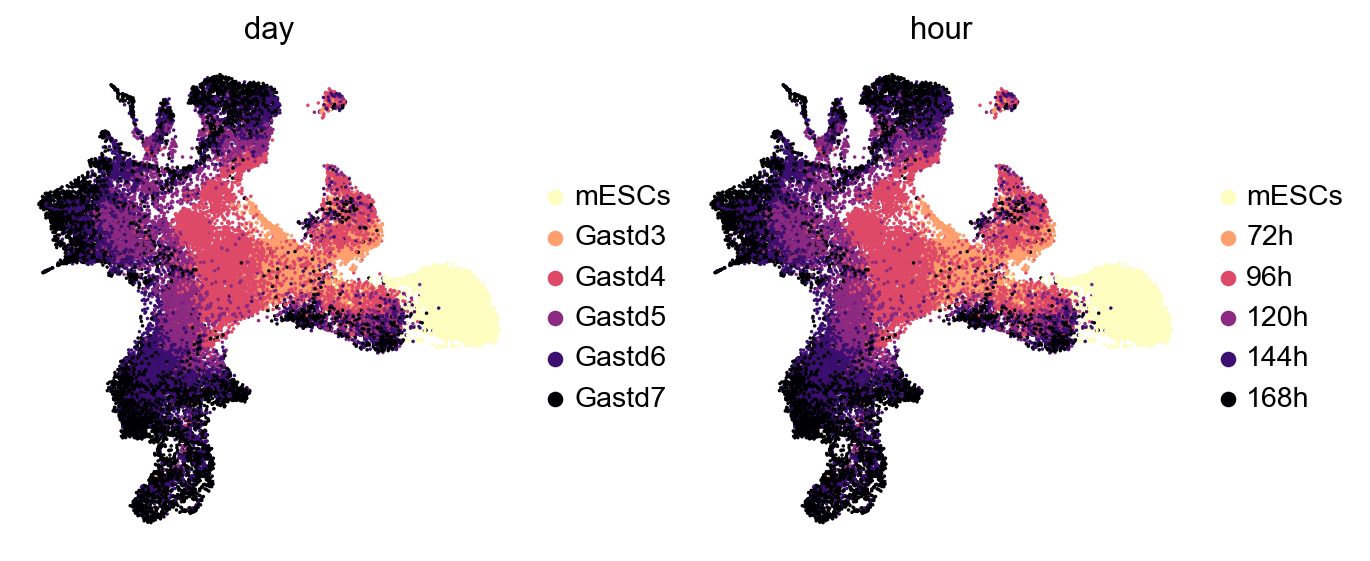

In [25]:
sc.pl.umap(adata,color=['day','hour'],palette='magma_r',frameon=False,
                         size = 10)

# Figure plots
Adjust dpi for high-res figures

In [26]:
dpi_fig = 80

sns.set_style('white')
sns.set_context('talk')
sns.set_style('ticks')

# UMAPs

saving figure to file figures\umapFig2b.png


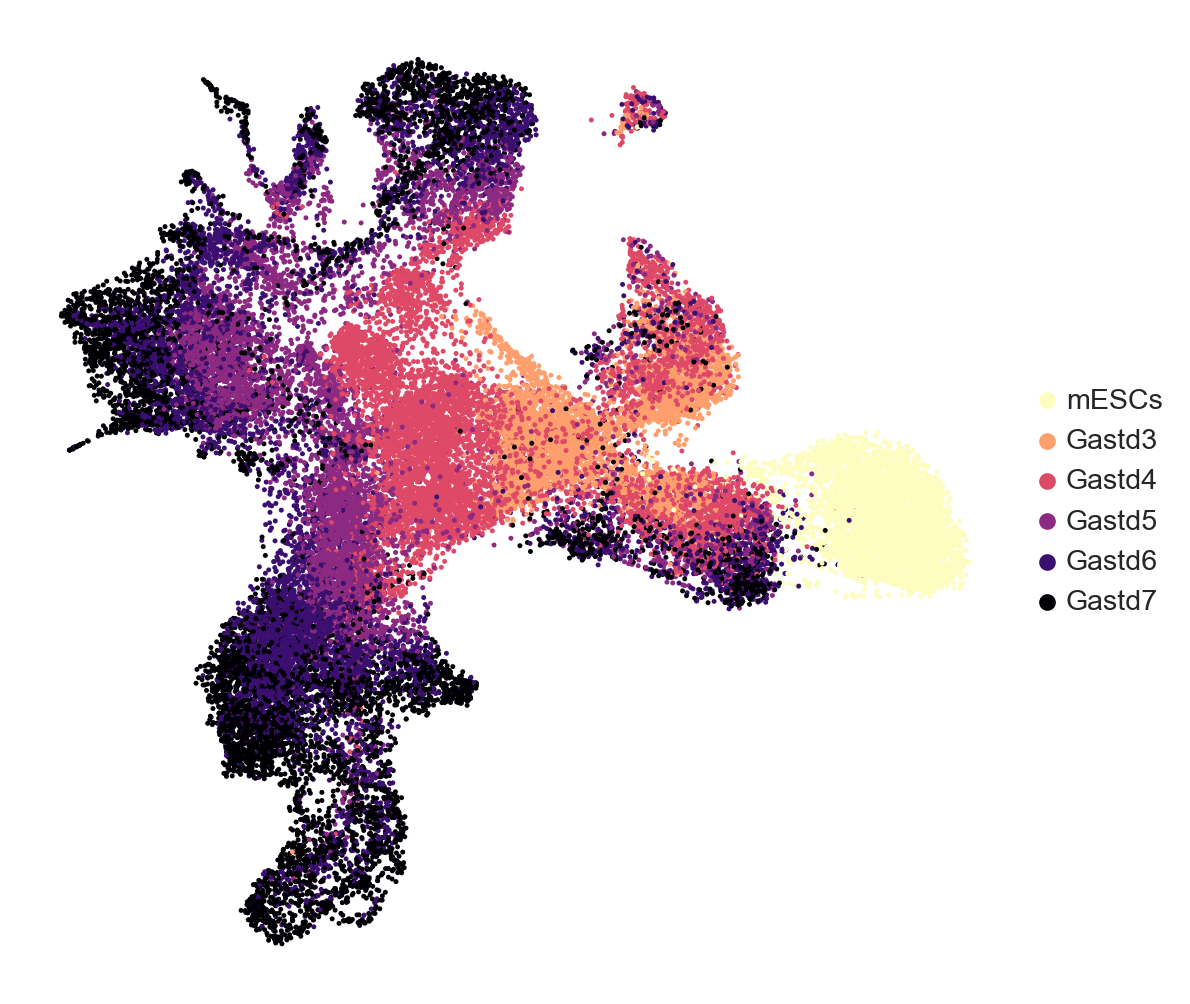

In [31]:
sc.set_figure_params(dpi=dpi_fig)
fig,ax = plt.subplots(figsize=(8,8))
sc.pl.umap(adata,color='day',ax=ax,frameon=False, size = 20, 
           palette = 'magma_r',title='', save='Fig2b.png')

saving figure to file figures\umapFigS2b.png


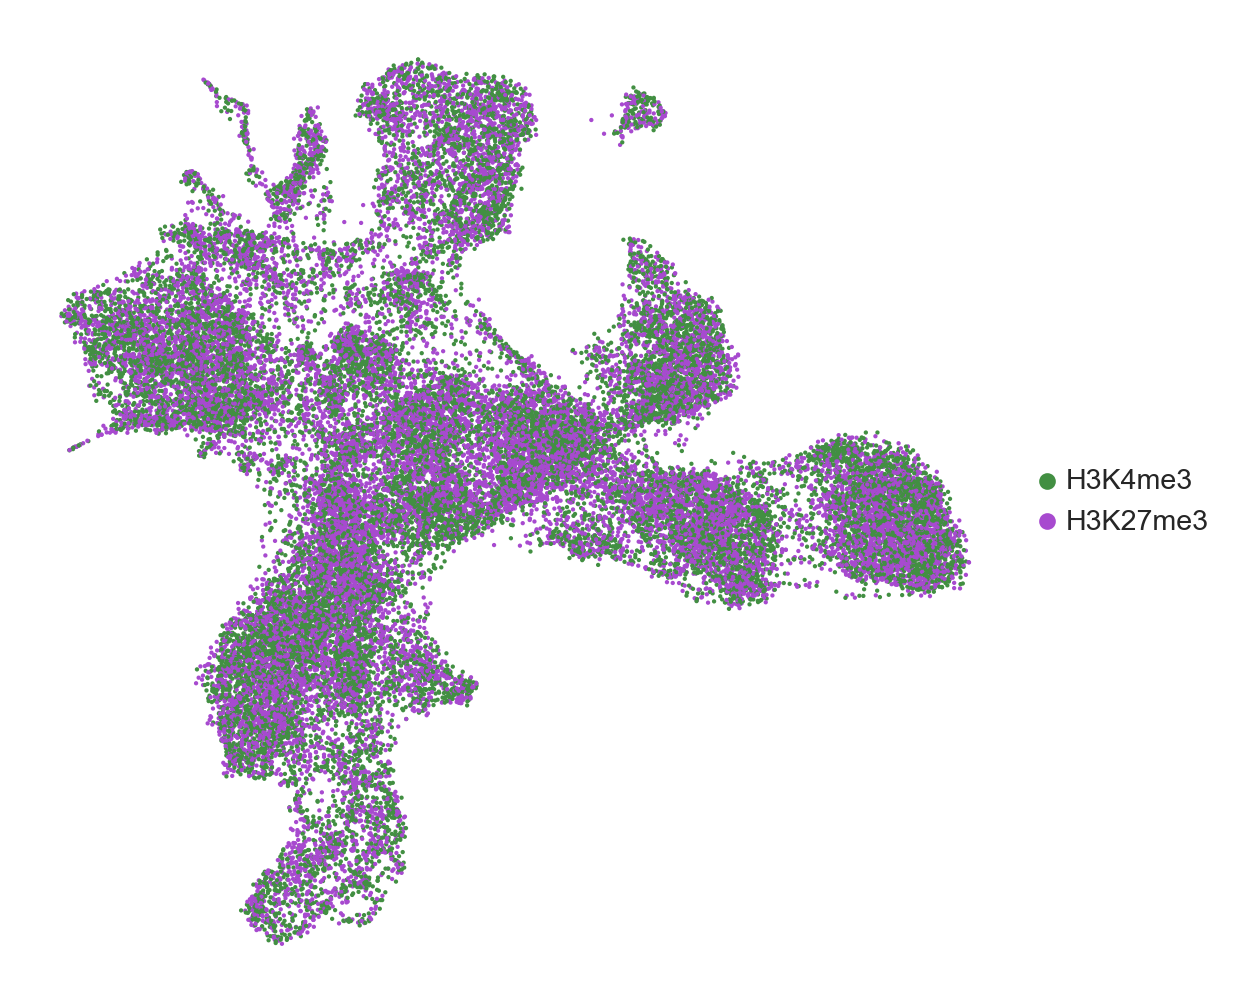

In [32]:
sc.set_figure_params(dpi=dpi_fig)
fig,ax = plt.subplots(figsize=(8,8))
new = sc.pp.subsample(adata, fraction=1., copy=True)
sc.pl.umap(new,color='mark',ax=ax,frameon=False, size = 15,#sort_order = False,
           palette = ['#428f42','#a74acf'], #['#008000', '#9400d3']
           alpha=1,title="", save='FigS2b.png')

In [33]:
adata.obs['celltype'] = adata.obs['celltype'].cat.reorder_categories([ 'mESCs','Primitive Streak','Caudal Epiblast', 'Epiblast', 'Naive PGCs', 'Epidermis Progenitors',
                                                                      'Caudal Mesoderm','Parietal Endoderm','PGCs','preSomitic/Wavefront','Nascent Mesoderm',
                                                                     'NMPs','LP/Intermediate Mesoderm','Neural Progenitors','Somite','Cardiac Mesoderm',
                                                                      'Endothelium','Visceral Endoderm','Dermomyotome','Erythrocytes','Reprogramming PGCs',
                                                                      'Sclerotome','Roof Plate Neural Tube', 'Floor Plate Neural Tube', 'ExE Endoderm',  
                                                                      'Cardiomyocytes','Pharyngeal Mesoderm', 'Early Motor Neurons','Late Motor Neurons',
                                                                      'Myotome', 'Megakaryocytes'])

cols = [ 'teal','mediumseagreen','forestgreen', # 'mESCs','Primitive Streak','Caudal Epiblast', 
        'palegreen',  'yellowgreen', #'Epiblast', 'Naive PGCs',
        'lightseagreen', 'hotpink', #'Epidermis Progenitors', 'Caudal Mesoderm',
        'chocolate','gold', # 'Parietal Endoderm','PGCs'
        'tomato','thistle',           # ,'preSomitic/Wavefront','Nascent Mesoderm',                                    
        'royalblue','blueviolet', # 'NMPs','LP/Intermediate Mesoderm'
        'cyan','mistyrose', #,'Neural Progenitors','Somite',
        'crimson','slategrey', #'Cardiac Mesoderm', 'Endothelium',
        'darkorange','indianred', #'Visceral Endoderm','Dermomyotome'
        'lightsteelblue', 'greenyellow', #,'Erythrocytes','Reprogramming PGCs',                                                         
        'plum','deepskyblue', # 'Sclerotome','Roof Plate Neural Tube',
        'navy', 'saddlebrown', # 'Floor Plate Neural Tube', 'ExE Endoderm',
        'indigo','darkred', # 'Cardiomyocytes','Pharyngeal Mesoderm',
        'dodgerblue','powderblue', #'Early Motor Neurons','Late Motor Neurons',
        'maroon', 'darkslategray'] # 'Myotome', 'Megakaryocytes'



In [34]:
adata.obs['celltype_binary'] =  adata.obs['celltype']

adata.rename_categories('celltype_binary', list(range(len(adata.obs['celltype'].unique()))) )

#adata.obs['celltype_binary'] = adata.obs['celltype_binary'].astype(str)
adata.obs['celltype_binary'] = adata.obs['celltype_binary'].astype('category')



saving figure to file figures\umapFig2c.png


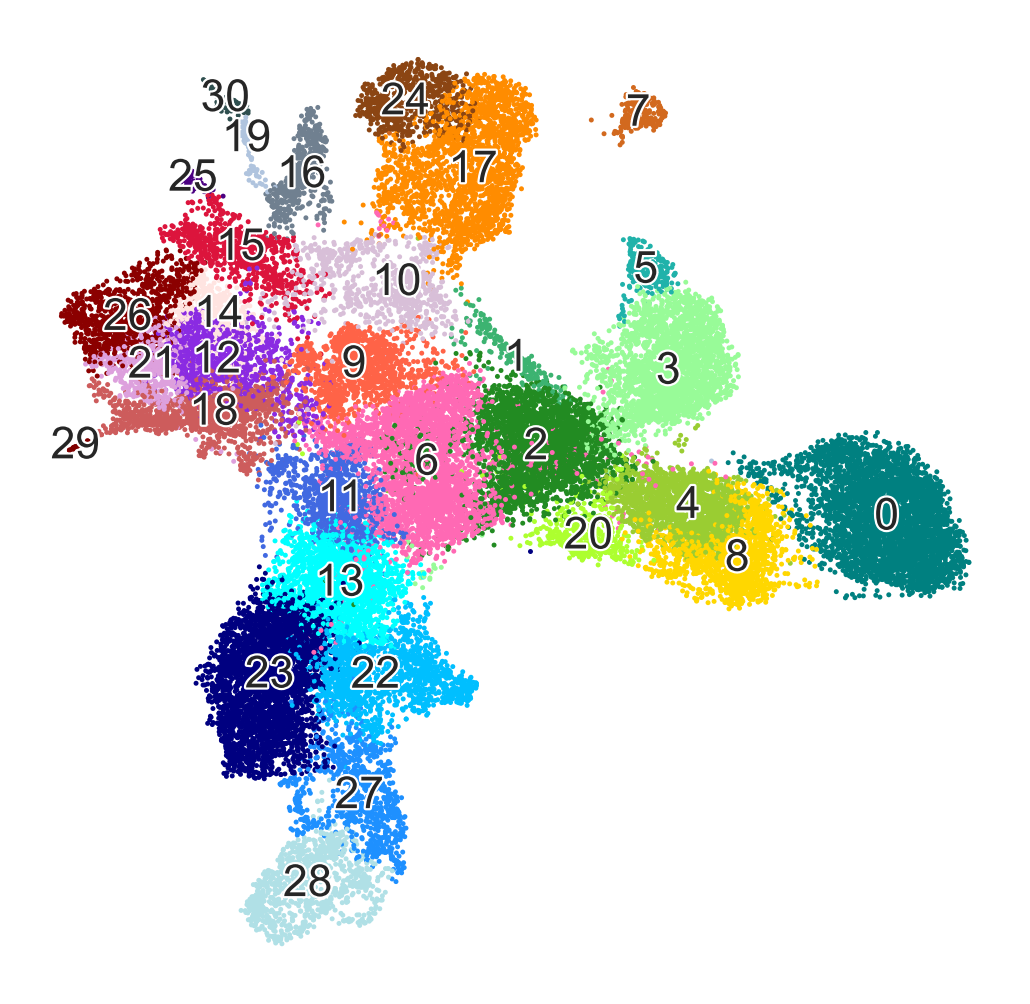

In [35]:
sc.set_figure_params(dpi=dpi_fig)
fig,ax = plt.subplots(figsize=(8,8))
sc.pl.umap(adata,color='celltype_binary',ax=ax,frameon=False, palette=cols,
           legend_loc = 'on data', legend_fontweight='light',legend_fontoutline='2',
           legend_fontsize=20, size =20,title='', save='Fig2c.png')

saving figure to file figures\umapFig2c_legend.png


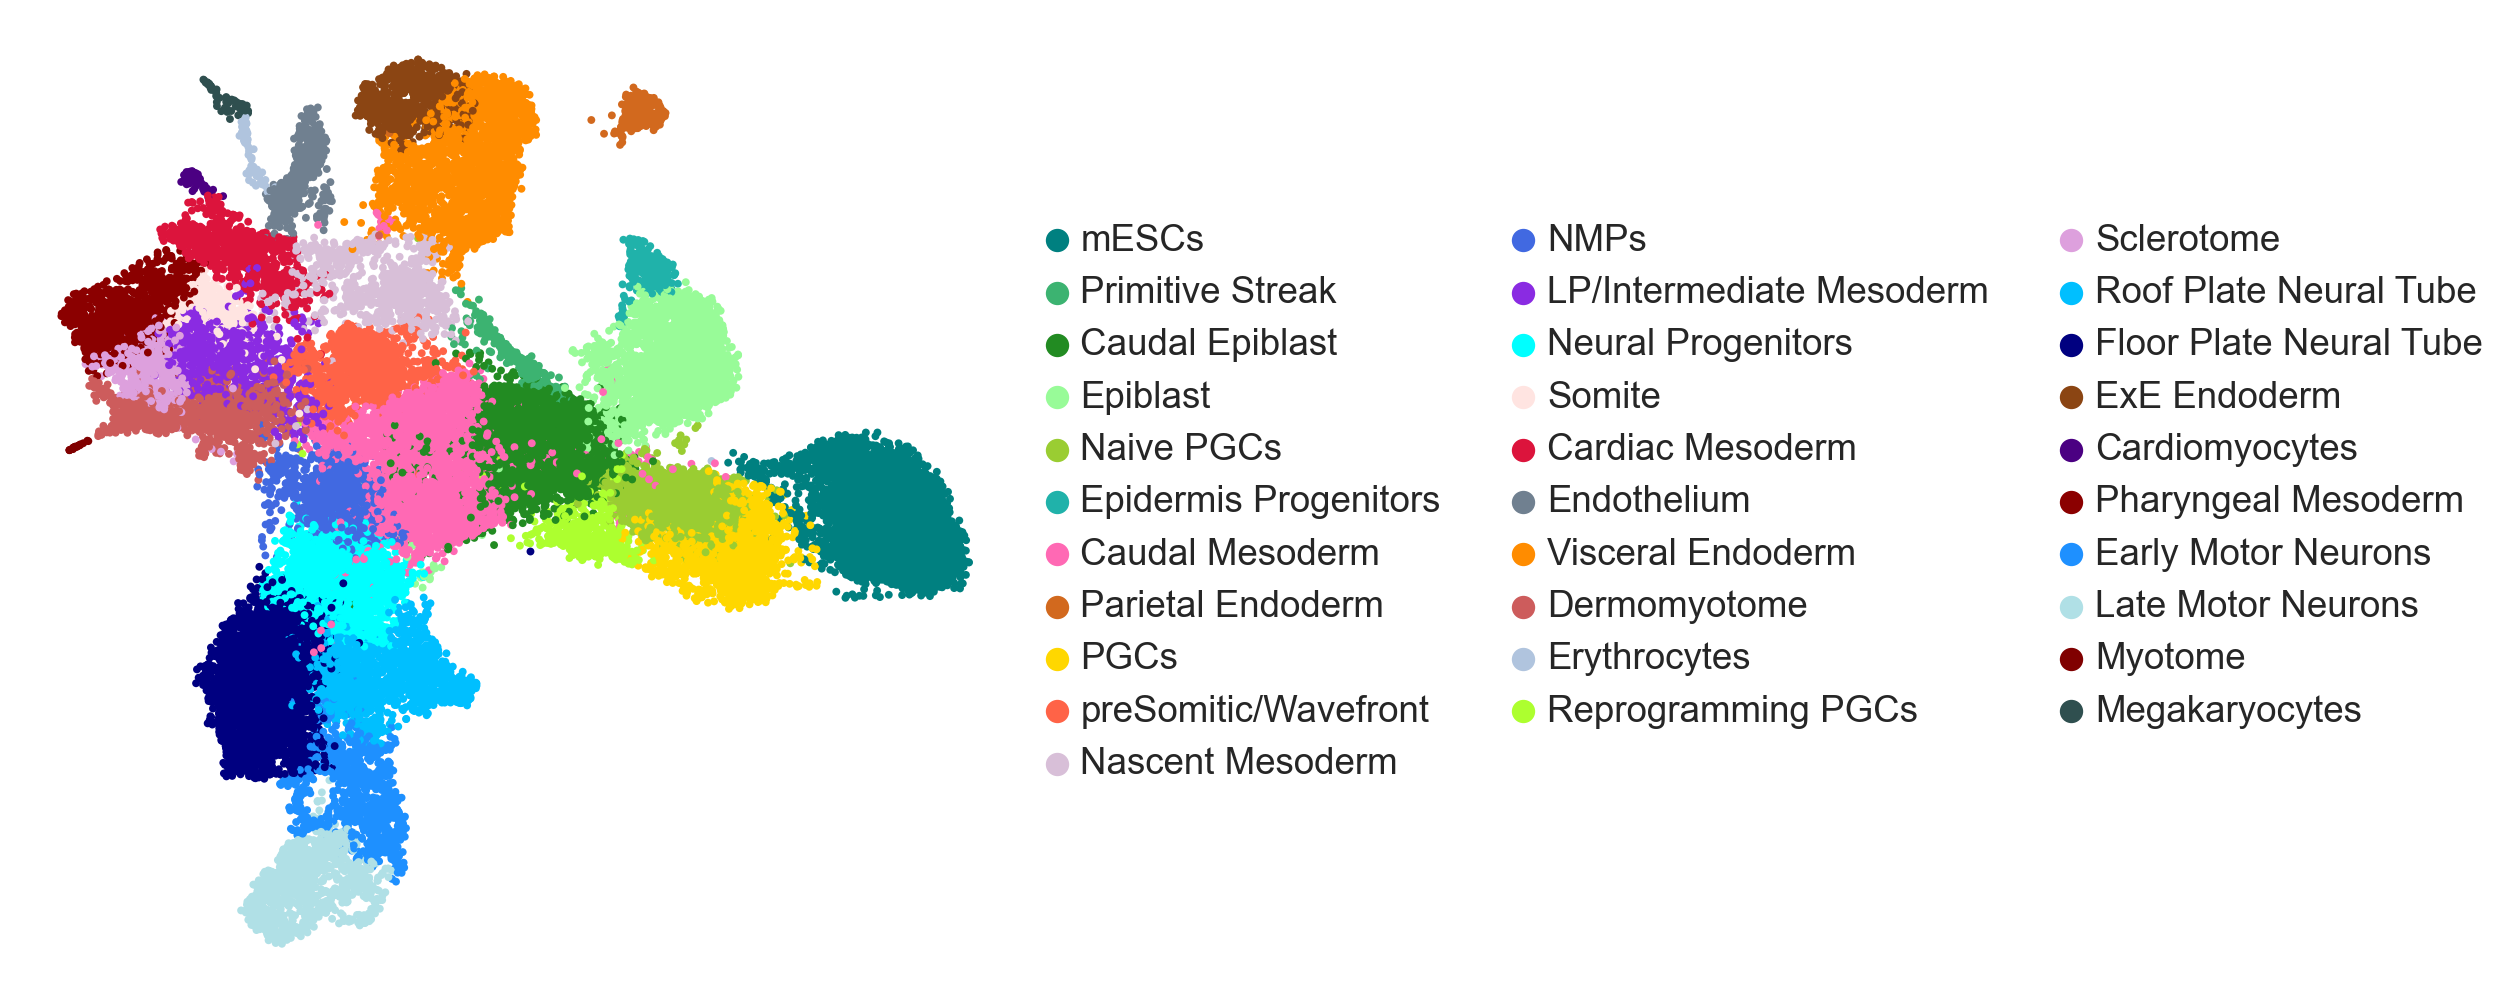

In [36]:
sc.set_figure_params(dpi=dpi_fig)
sns.set_context('talk')
fig,ax = plt.subplots(figsize=(8,8))
sc.pl.umap(adata,color='celltype',ax=ax,frameon=False, palette=cols,
   #        legend_loc = 'on data', legend_fontweight='light',legend_fontoutline='2',
           #legend_fontsize=20, 
           size =50,title='', save='Fig2c_legend.png')

saving figure to file figures\umapFig2f2.png


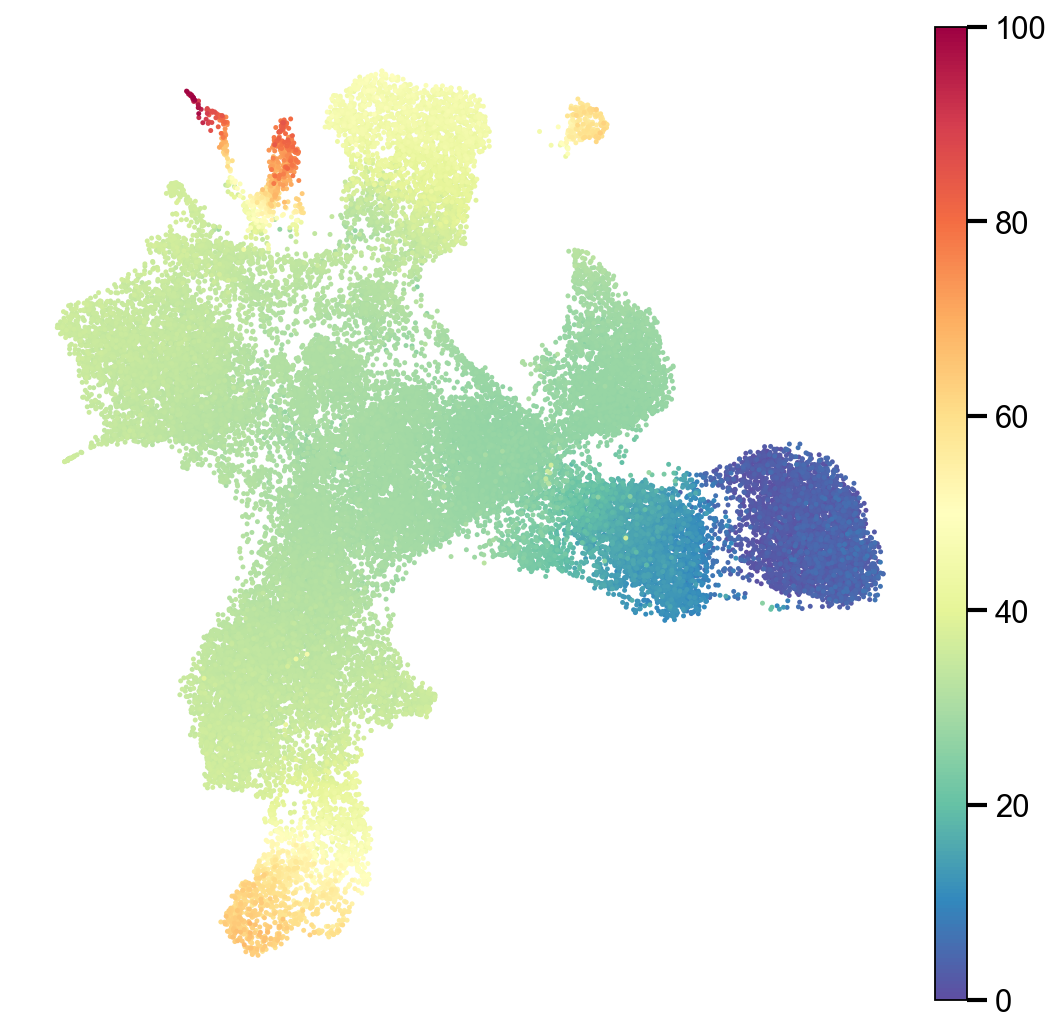

In [40]:
sc.set_figure_params(dpi=dpi_fig)
fig,ax = plt.subplots(figsize=(8,8))
sc.pl.umap(adata,color='PT1',ax=ax,frameon=False, size = 20, legend_loc = None,#legend_loc = 'on data', legend_fontweight='light',legend_fontoutline='2',legend_fontsize=10, size =60, 
           cmap = 'Spectral_r', title='', save='Fig2f2.png')

saving figure to file figures\umap_figS2d.png


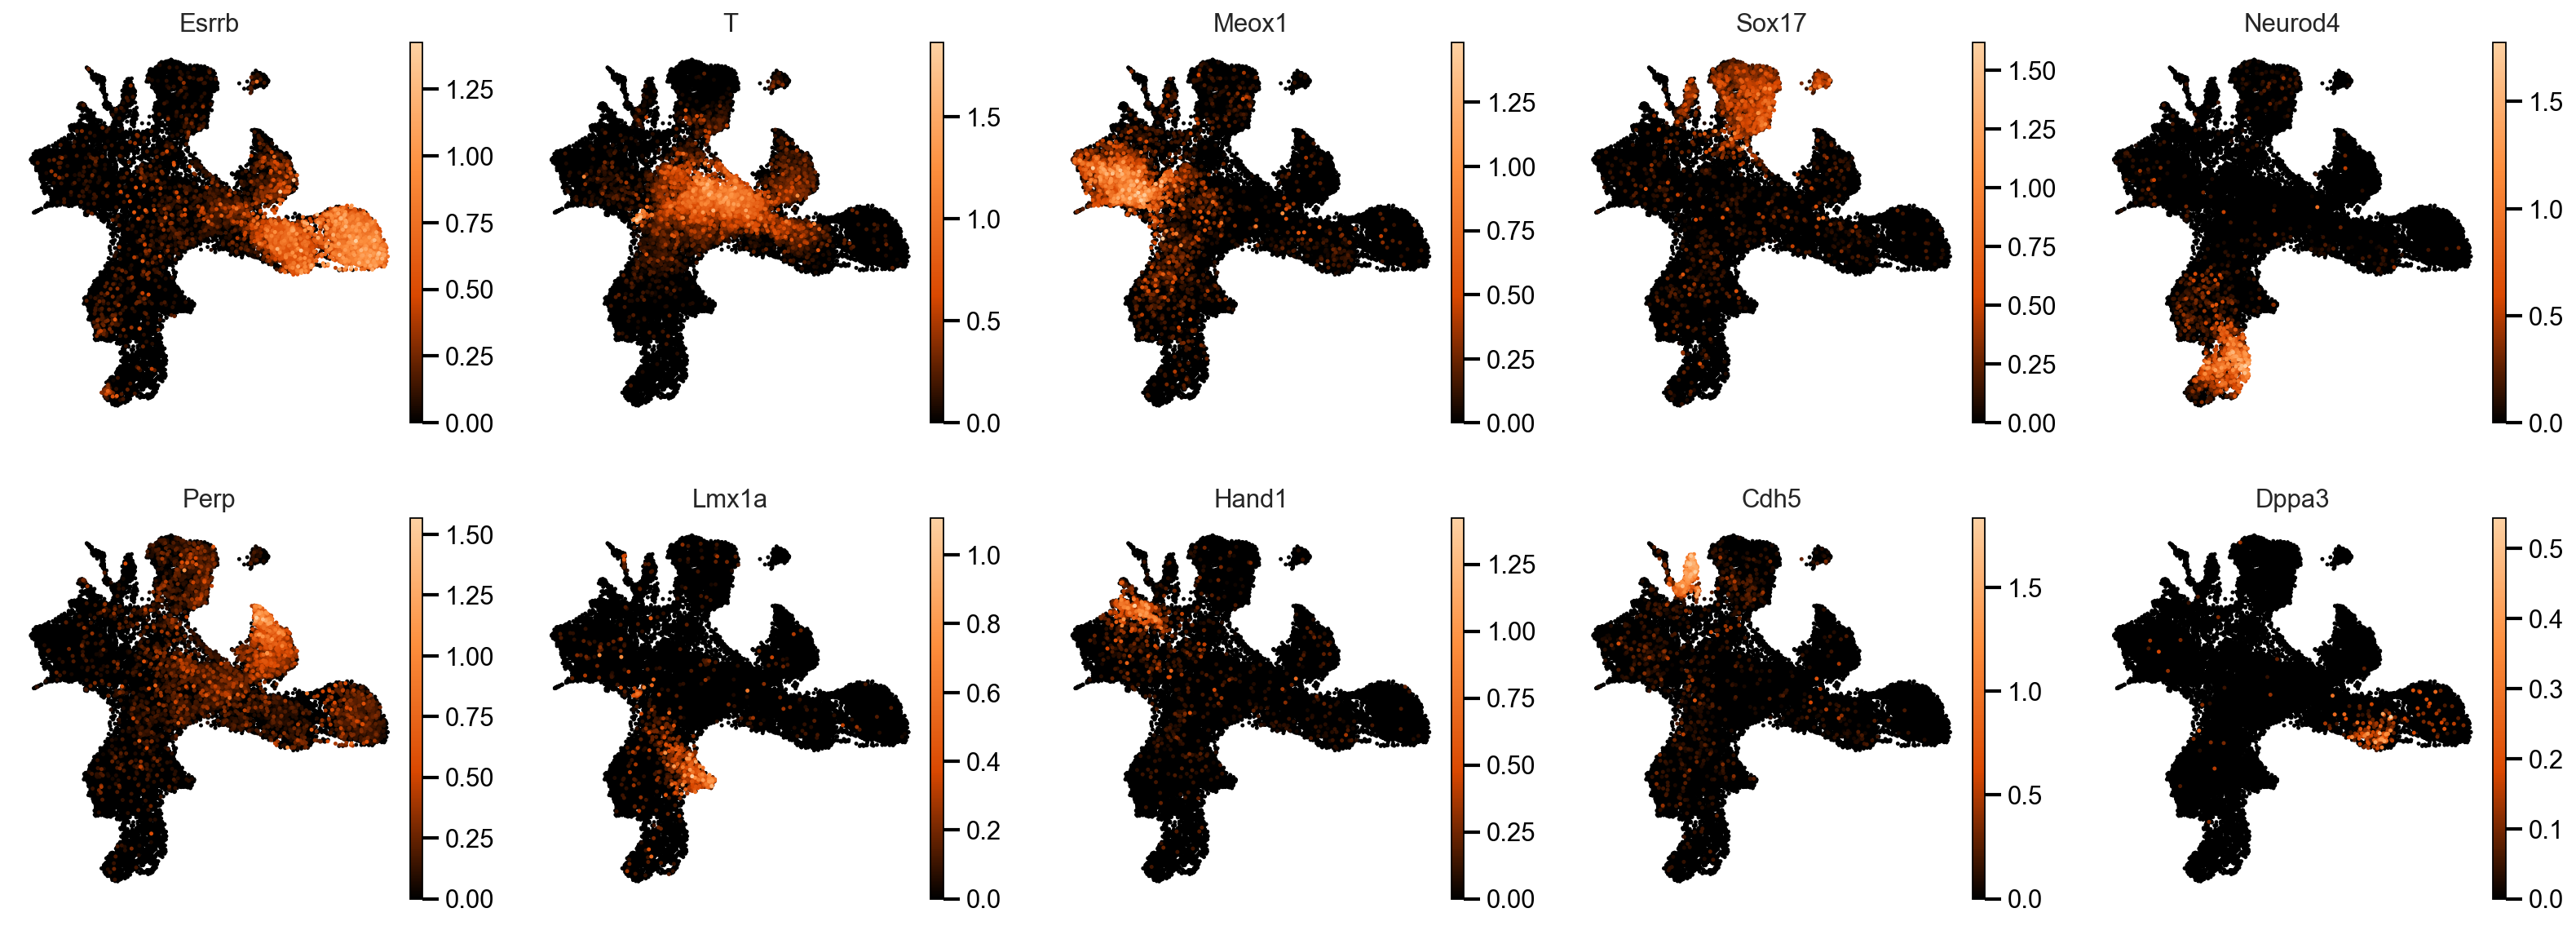

In [41]:
sc.set_figure_params(dpi=dpi_fig)
genes = ['Esrrb','T','Meox1','Sox17', 'Neurod4',
         'Perp','Lmx1a','Hand1','Cdh5','Dppa3']

sc.pl.umap(adata,color=genes,frameon=False, size = 20,ncols = 5,#legend_loc = 'on data', legend_fontweight='light',legend_fontoutline='2',legend_fontsize=10, size =60, 
        cmap=trans, save='_figS2d.png')

# Violin plots

log_counts


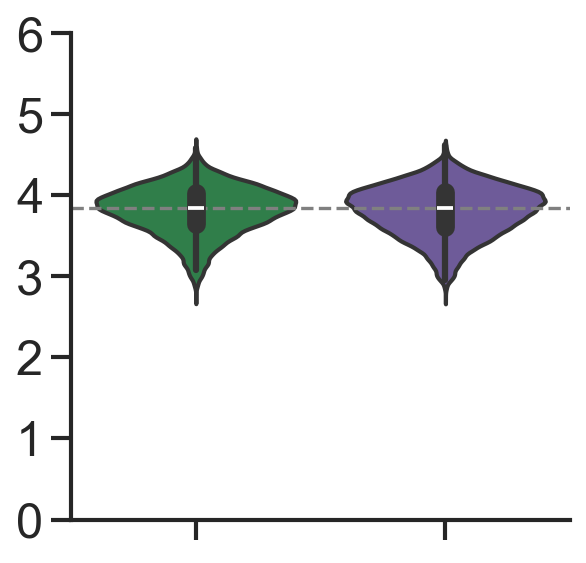

log_counts_proteincoding


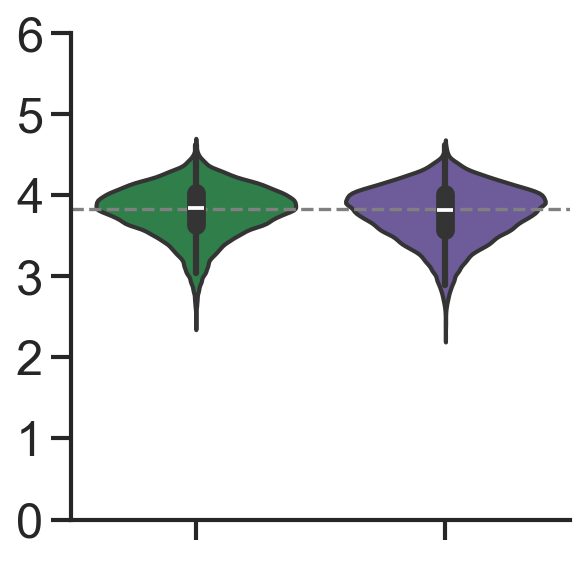

In [48]:
sc.set_figure_params(dpi=dpi_fig)
sns.set_style('white')
sns.set_context('talk')
sns.set_style('ticks')

adata.obs['log_counts'] = np.log10(adata.obs['n_counts'])
adata.obs['log_counts_proteincoding'] = np.log10(adata.obs['n_counts_proteincoding'])
adata.obs['log_genes'] = np.log10(adata.obs['n_genes'])
stats = ['log_counts','log_counts_proteincoding']#['n_counts','log_counts','n_counts_proteincoding','log_counts_proteincoding','n_genes','log_genes','percent_mito']
reps = ['#0173b2', '#de8f05', '#029e73']
pal = ['#febb81', '#f8765c', '#d3436e', '#982d80', '#5f187f', '#221150']
marks = ['#238B45','#6A51A3']

from matplotlib.ticker import FormatStrFormatter

for x in stats:
    print(x)
  #  ax = sns.stripplot(x=adata.obs['day'],
  #                     y=adata.obs[x], color = 'black',jitter=0.3,size=0.5)

    plt.axhline(adata.obs[x].median(), 
                color = 'grey', linestyle = '--', lw = 1.5)
    ax = sns.violinplot(x=adata.obs['mark'],scale = 'width',bw = .1,
                        y=adata.obs[x],palette = marks)#,hue = adata.obs['state'])
    #add_stat_annotation(ax, x=adata2.obs['state'],y=adata2.obs[x], test="Mann-Whitney",box_pairs = [adata2.obs['state'].unique()], loc='outside', verbose=2,text_format='star')
    ax.set_xlabel("")
    ax.set_ylabel("")
    plt.setp(ax.xaxis.get_majorticklabels(),rotation = 0, ha='center', fontsize = 22)
    plt.setp(ax.yaxis.get_majorticklabels(), ha='right', fontsize = 22)
    plt.title(x)
    ax.set_ylim([0,6])
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
    ax.set_xticklabels("")
    ax.set_title("")

    sns.despine()

    plt.savefig('TCHIC_figS2_a1left.pdf', dpi=300, format='pdf', bbox_inches='tight')
    plt.show()

log_counts


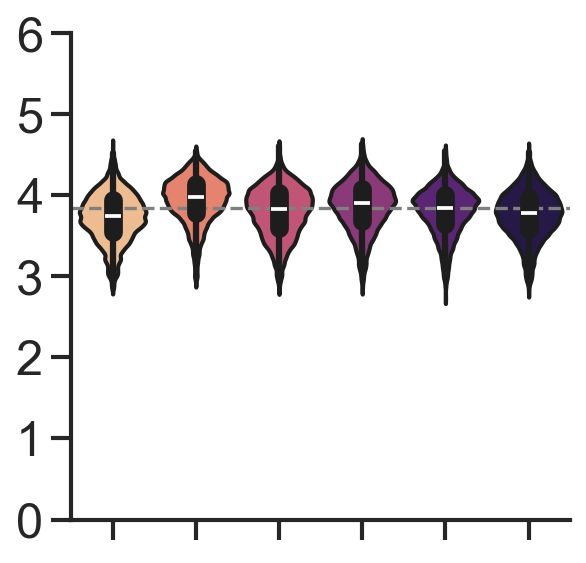

log_counts_proteincoding


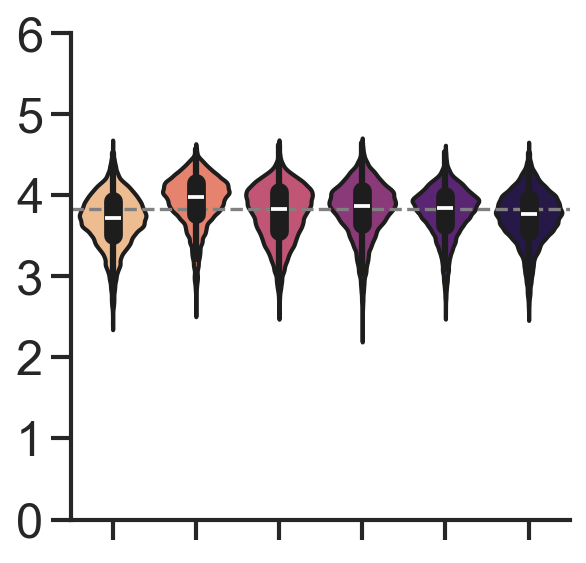

In [49]:
stats = ['log_counts','log_counts_proteincoding']#['n_counts','log_counts','n_counts_proteincoding','log_counts_proteincoding','n_genes','log_genes','percent_mito']
reps = ['#0173b2', '#de8f05', '#029e73']
pal = ['#febb81', '#f8765c', '#d3436e', '#982d80', '#5f187f', '#221150']
marks = ['green','purple']
marks
for x in stats:
    print(x)
    plt.axhline(adata.obs[x].median(), 
                color = 'grey', linestyle = '--', lw = 1.5)
    ax = sns.violinplot(x=adata.obs['day'],scale = 'width',bw = .1,
                        y=adata.obs[x],palette = pal)#,hue = adata.obs['state'])
    #add_stat_annotation(ax, x=adata2.obs['state'],y=adata2.obs[x], test="Mann-Whitney",box_pairs = [adata2.obs['state'].unique()], loc='outside', verbose=2,text_format='star')
    ax.set_xlabel("")
    ax.set_ylabel("")
    plt.setp(ax.xaxis.get_majorticklabels(),rotation = 45, ha='right', fontsize = 22)
    plt.setp(ax.yaxis.get_majorticklabels(), ha='right', fontsize = 22)
    plt.title(x)
    ax.set_ylim([0,6])
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
    ax.set_xticklabels("")
    ax.set_title("")
    sns.despine()

    plt.savefig('TCHIC_figS2_a1right.pdf', dpi=300, format='pdf', bbox_inches='tight')
    plt.show()

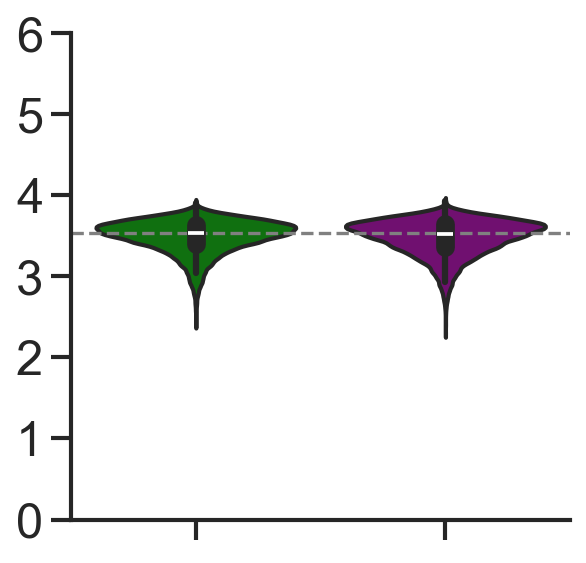

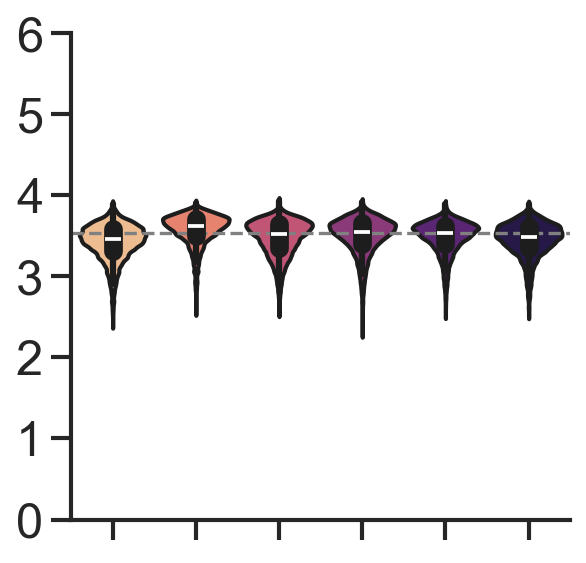

In [50]:
reps = ['#0173b2', '#de8f05', '#029e73']
pal = ['#febb81', '#f8765c', '#d3436e', '#982d80', '#5f187f', '#221150']
#marks = ['green','purple']

#log genes
plt.axhline(adata.obs['log_genes'].median(), 
                color = 'grey', linestyle = '--', lw = 1.5)
ax = sns.violinplot(x=adata.obs['mark'],scale = 'width',bw = .1,
                    y=adata.obs['log_genes'],palette = marks)#,hue = adata.obs['state'])
ax.set_xlabel("")
ax.set_ylabel("")
plt.setp(ax.xaxis.get_majorticklabels(),rotation = 0, ha='center', fontsize = 22)
plt.setp(ax.yaxis.get_majorticklabels(), ha='right', fontsize = 22)
plt.title(x)
ax.set_ylim([0,6])
ax.set_title("")
ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
ax.set_xticklabels("")
ax.set_title("")
sns.despine()
plt.show()

plt.axhline(adata.obs['log_genes'].median(), 
                color = 'grey', linestyle = '--', lw = 1.5)
ax = sns.violinplot(x=adata.obs['hour'],scale = 'width',bw = .1,
                    y=adata.obs['log_genes'],palette = pal)#,hue = adata.obs['state'])
ax.set_xlabel("")
ax.set_ylabel("")
plt.setp(ax.xaxis.get_majorticklabels(),rotation = 90, ha='center', fontsize = 22)
plt.setp(ax.yaxis.get_majorticklabels(), ha='right', fontsize = 22)
plt.title(x)
ax.set_ylim([0,6])
ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
ax.set_ylim([0,6])
ax.set_xticklabels("")
ax.set_title("")
sns.despine()

plt.savefig('TCHIC_figS2_a2.pdf', dpi=300, format='pdf', bbox_inches='tight')
plt.show()

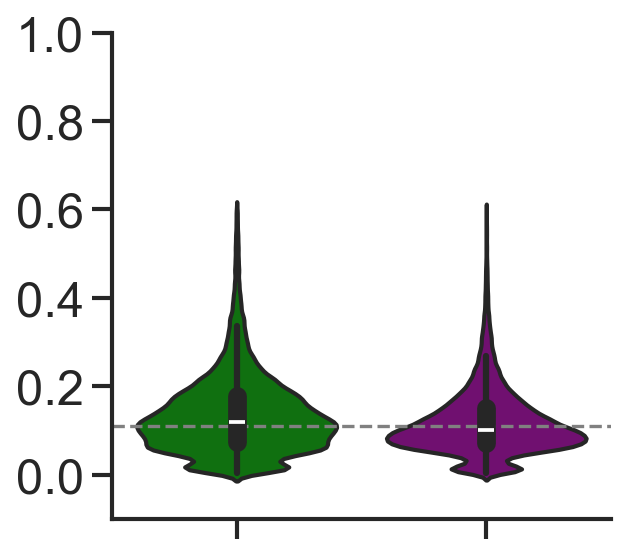

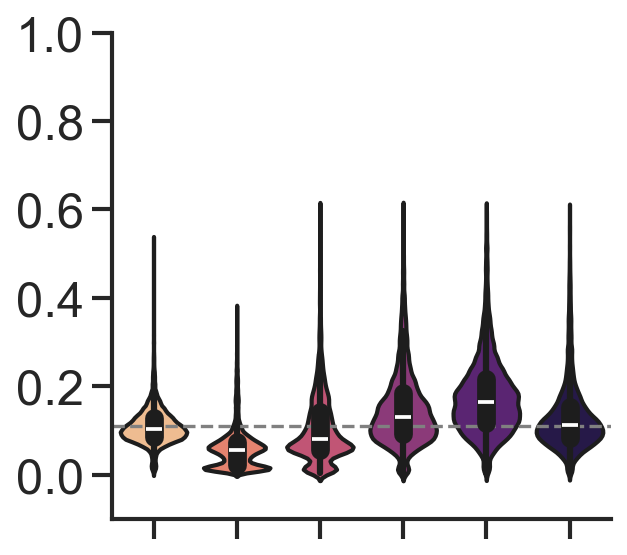

In [51]:
reps = ['#0173b2', '#de8f05', '#029e73']
pal = ['#febb81', '#f8765c', '#d3436e', '#982d80', '#5f187f', '#221150']
#marks = ['green','purple']

adata.obs['percent_mito2'] = adata.obs['percent_mito'] * 100

plt.axhline(adata.obs['percent_mito'].median(), 
                color = 'grey', linestyle = '--', lw = 1.5)
ax = sns.violinplot(x=adata.obs['mark'],scale = 'width',bw = .1,
                    y=adata.obs['percent_mito'],palette = marks)#,hue = adata.obs['state'])
ax.set_xlabel("")
ax.set_ylabel("")
plt.setp(ax.xaxis.get_majorticklabels(),rotation = 0, ha='center', fontsize = 22)
plt.setp(ax.yaxis.get_majorticklabels(), ha='right', fontsize = 22)
plt.title(x)
ax.set_ylim([-0.1,1])
ax.set_title("")
#ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
ax.set_xticklabels("")
ax.set_title("")
sns.despine()
plt.show()

plt.axhline(adata.obs['percent_mito'].median(), 
                color = 'grey', linestyle = '--', lw = 1.5)
ax = sns.violinplot(x=adata.obs['hour'],scale = 'width',bw = .1,
                    y=adata.obs['percent_mito'],palette = pal)#,hue = adata.obs['state'])
ax.set_xlabel("")
ax.set_ylabel("")
plt.setp(ax.xaxis.get_majorticklabels(),rotation = 90, ha='center', fontsize = 22)
plt.setp(ax.yaxis.get_majorticklabels(), ha='right', fontsize = 22)
plt.title(x)

#ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
ax.set_ylim([-0.1,1])
ax.set_xticklabels("")
ax.set_title("")
sns.despine()

plt.savefig('TCHIC_figS2_a3.pdf', dpi=300, format='pdf', bbox_inches='tight')
plt.show()

# Barplots

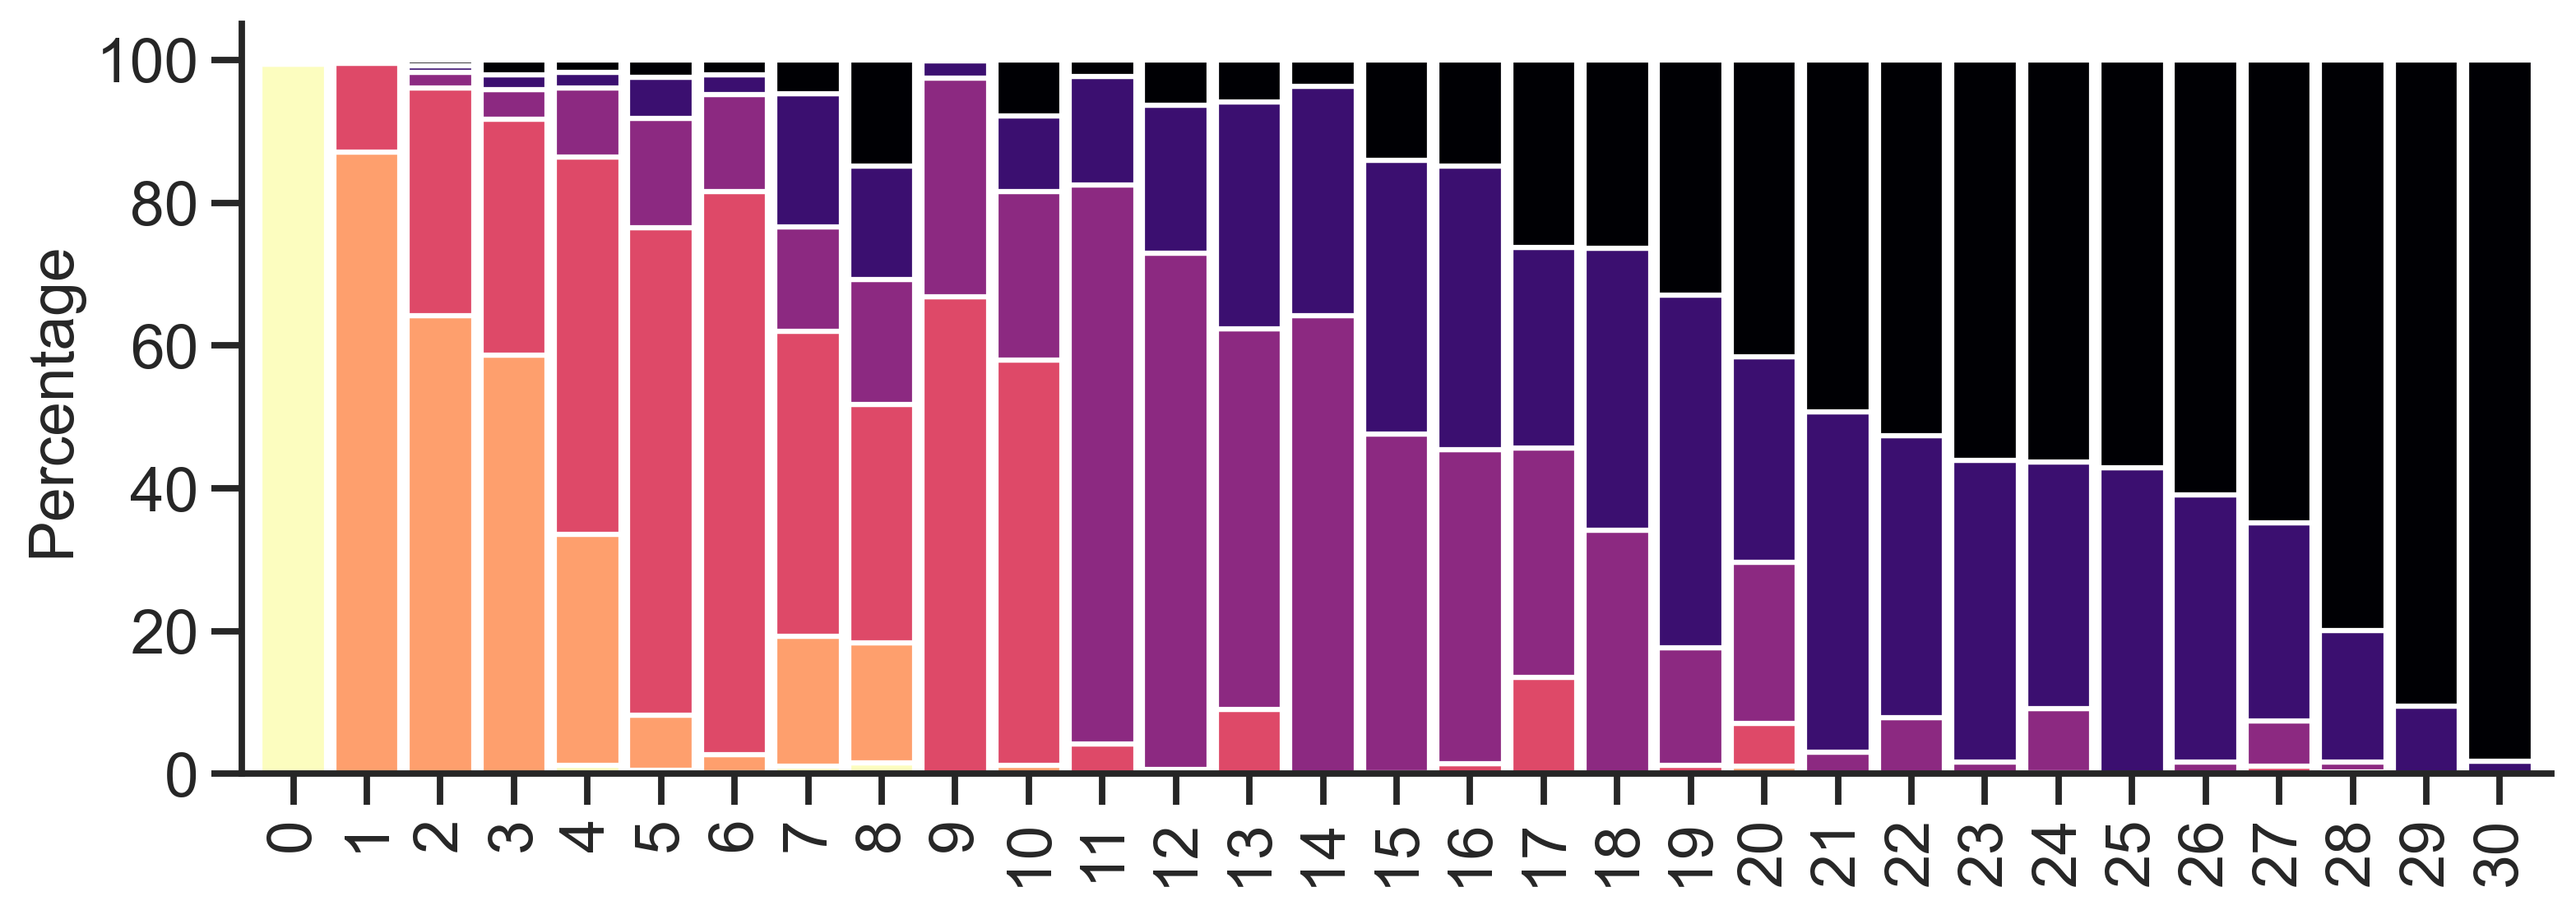

In [53]:
ct_order = [ 'mESCs','Primitive Streak','Caudal Epiblast', 'Epiblast', 
             'Epidermis Progenitors',
            'Naive PGCs','PGCs','Reprogramming PGCs',
            'Caudal Mesoderm','preSomitic/Wavefront','Nascent Mesoderm',
            'LP/Intermediate Mesoderm','Somite','Cardiac Mesoderm','Dermomyotome',
            'Sclerotome','Cardiomyocytes','Pharyngeal Mesoderm', 'Myotome',
            'Parietal Endoderm','Visceral Endoderm','ExE Endoderm',  
            
            'NMPs','Neural Progenitors','Roof Plate Neural Tube',
            'Floor Plate Neural Tube','Early Motor Neurons',
            'Late Motor Neurons',
            'Endothelium','Erythrocytes', 'Megakaryocytes']

sns.set_style('white')
sns.set_style('ticks')
sns.set_context('talk')

var1 = 'celltype'
var2 = 'hour'
dpi = 150 
fontsize = 28 
figsize = (12,4)

counts = collections.defaultdict(dict)
for gastruloid in adata.obs[var1].unique():
    counts[gastruloid]['total'] = adata.obs[var1].str.count(gastruloid).sum()
    for celltype in adata.obs[var2].unique():
        counts[gastruloid][celltype] =  adata.obs[adata.obs[var2] == celltype][var1].str.count(gastruloid).sum()

celltype_counts = pd.DataFrame(counts).T
celltype_counts = celltype_counts.reset_index().rename(columns={'index':'var1'})

new = celltype_counts.set_index('var1').T
new['Total'] = new.sum(axis=1)
percentages = new.T[new.loc['total'] > 10].T

for sample in percentages:
    percentages[sample] = percentages[sample]/percentages[sample]['total']*100
percentages = percentages[adata.obs[var1].unique().sort_values()]
percentages = percentages.loc[adata.obs[var2].unique().sort_values()]


p_name = var2 + '_colors'
palette = adata.uns[p_name]

fig,ax = plt.subplots(figsize=(12,6), dpi = dpi)
sns.set_style('ticks')
ax = percentages.T.plot.bar(stacked=True,figsize=figsize,fontsize = 18,
                            width=0.90,
                                                     color = palette, ax = ax)
ax.set_xlabel("",)
ax.set_title('',)
ax.set_ylabel("Percentage")#,fontsize=fontsize)
ax.tick_params(axis='x', rotation=90)
plt.setp(ax.xaxis.get_majorticklabels(), ha='center')
ax.set_xticklabels(['0','1','2','3','4','5','6','7','8','9','10','11','12','13','14','15',
           '16','17','18','19','20','21','22','23','24','25','26','27','28','29','30'])
sns.despine()
ax.legend([],frameon=False)

#ax.legend(frameon = False,bbox_to_anchor=[1, 0.5])
plt.savefig('Fig2d.pdf', dpi=300, format='pdf', bbox_inches='tight')
plt.show()

# stackplot of celltypes over time

In [54]:
sns.set_style('white')
sns.set_context('talk')


In [57]:
counts = pd.DataFrame(adata.obs[['hour','lineage']].value_counts()).sort_values(by='hour')
counts = counts.rename(columns={0:'count'}).reset_index()
counts_reformat = counts.pivot(index='hour', columns='lineage', values='count')#.reset_index()
counts_reformat = counts_reformat.fillna(0)
counts_reformat = counts_reformat.reset_index()

In [58]:
countsf = pd.DataFrame(adata.obs[['hour','celltype']].value_counts()).sort_values(by='hour')
countsf = countsf.rename(columns={0:'count'}).reset_index()
countsf
countsf_reformat = countsf.pivot(index='hour', columns='celltype', values='count')#.reset_index()
countsf_reformat = countsf_reformat.fillna(0)
countsf_reformat = countsf_reformat.reset_index()

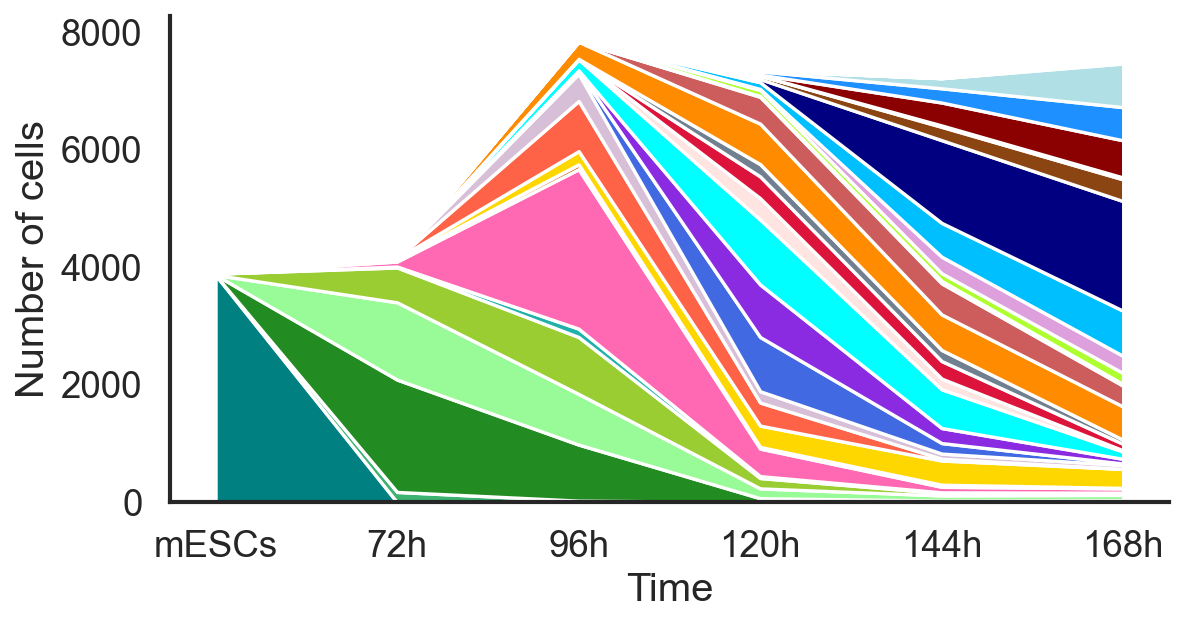

In [59]:
color_map = list(adata.uns['celltype_colors'])

fig,ax = plt.subplots(figsize=(8,4))

list_celltypes = list(pd.Categorical(adata.obs['celltype']).categories)

plt.stackplot(countsf_reformat.hour, 
              [countsf_reformat[x] for x in list_celltypes],
              labels=list_celltypes,
             colors = color_map)
sns.despine()

#add legend
#plt.legend(loc='upper left')

#add axis labels
plt.xlabel('Time')
plt.ylabel('Number of cells')

#display area chart
plt.show()

In [61]:
countsf_perc = countsf.pivot(index='hour', columns='celltype', values='count')#.reset_index()
countsf_perc = countsf_perc.fillna(0)
for tp in countsf_perc.index:
    countsf_perc.loc[tp] = countsf_perc.loc[tp]/sum(countsf_perc.loc[tp])*100

countsf_perc = countsf_perc.reset_index()

color_map = list(adata.uns['celltype_colors'])
list_celltypes = list(pd.Categorical(adata.obs['celltype']).categories)

res = {list_celltypes[i]: color_map[i] for i in range(len(list_celltypes))}

key_order = ['mESCs', 'Primitive Streak', 'Caudal Epiblast', 'Epiblast', 'Naive PGCs', 'Epidermis Progenitors', 'PGCs','Reprogramming PGCs','Caudal Mesoderm',
             'preSomitic/Wavefront', 'Nascent Mesoderm','LP/Intermediate Mesoderm','Somite', 'Cardiac Mesoderm','Dermomyotome','Sclerotome',
              'Cardiomyocytes', 'Pharyngeal Mesoderm','Myotome','NMPs','Neural Progenitors','Roof Plate Neural Tube','Floor Plate Neural Tube',
              'Early Motor Neurons','Late Motor Neurons','Parietal Endoderm','Visceral Endoderm','ExE Endoderm','Endothelium','Erythrocytes','Megakaryocytes']

new_order = collections.OrderedDict((k, res[k]) for k in key_order)

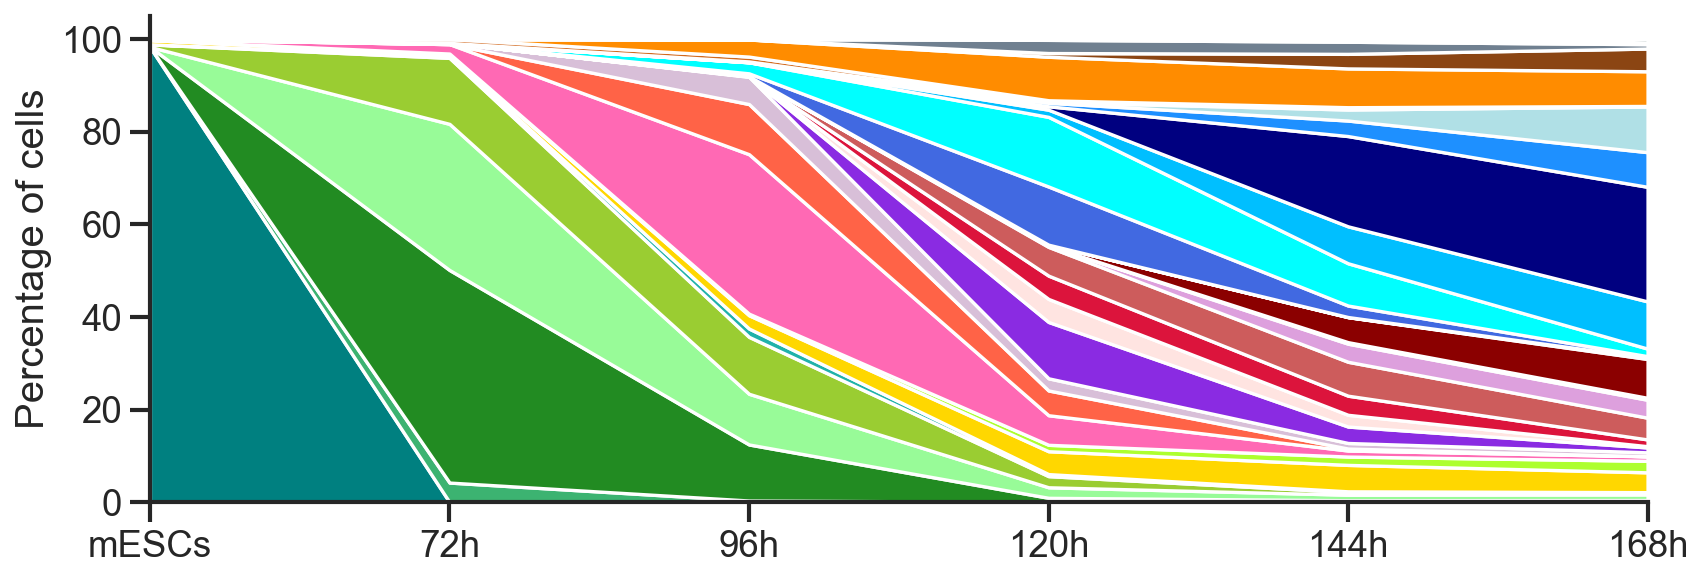

In [62]:
sns.set_style('white')
sns.set_style('ticks')
sns.set_context('talk')

list_celltypes = new_order.keys()
color_map = new_order.values()

fig,ax = plt.subplots(figsize=(12,4))


plt.stackplot(countsf_perc.hour, 
              [countsf_perc[x] for x in list_celltypes],
              labels=list_celltypes,
             colors = color_map)
sns.despine()

#add legend
#plt.legend(loc='upper left')

#add axis labels
plt.xlabel('')
plt.ylabel('Percentage of cells')
plt.margins(x=0)
#display area chart

plt.savefig('Fig2e.pdf', dpi=300, format='pdf', bbox_inches='tight')
plt.show()

# Heatmaps

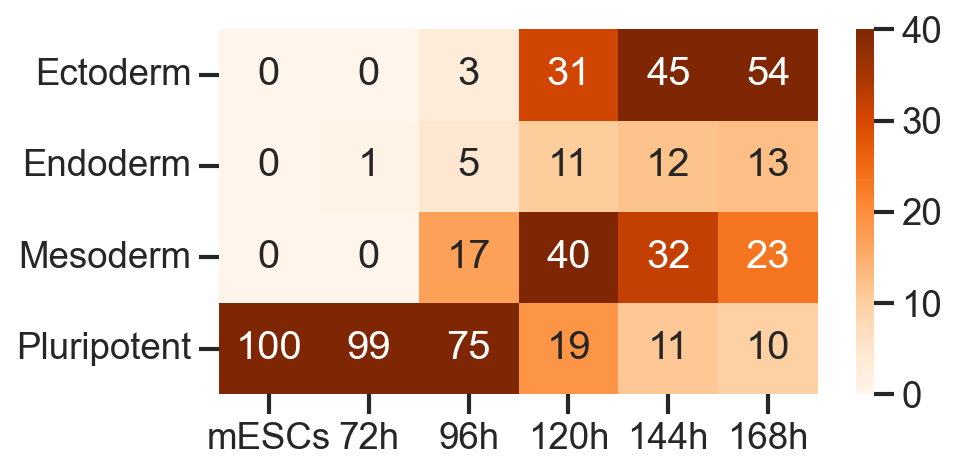

In [63]:
fig,ax = plt.subplots(figsize=(6,3), dpi = dpi_fig)
ax = sns.heatmap(pd.crosstab(adata.obs['lineage'], adata.obs['hour'], normalize = 'columns')*100,vmin = 0, vmax = 40,ax=ax,
            cmap='Oranges',
           annot=True,fmt='.0f')
ax.set_xlabel("")
ax.set_ylabel("")
plt.show()
plt.savefig('FigS2e.pdf', dpi=300, format='pdf', bbox_inches='tight')

<Figure size 320x320 with 0 Axes>

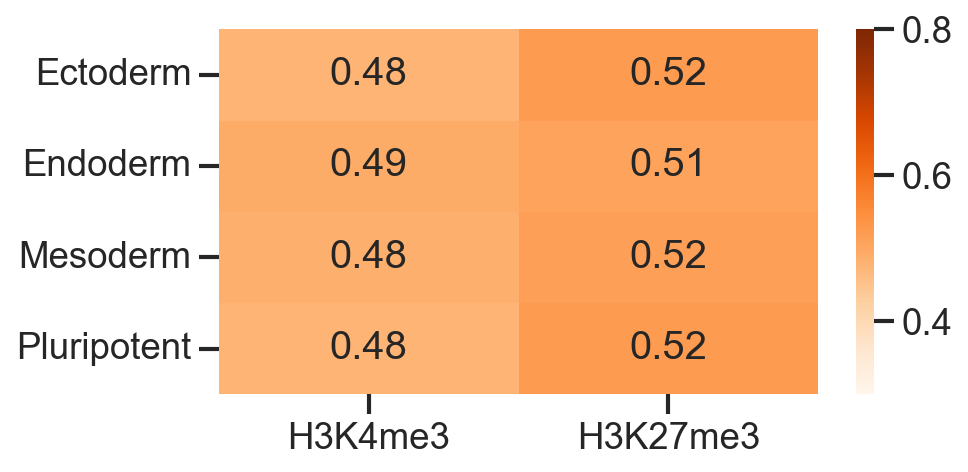

In [64]:
fig,ax = plt.subplots(figsize=(6,3), dpi = dpi_fig)

sns.heatmap(pd.crosstab(adata.obs['lineage'], adata.obs['mark'],normalize='index' ),ax=ax,vmin = 0.3,vmax=0.8,#[['Pluripotent','Mesoderm','Haemogenic','Endoderm','Ectoderm']]*100,
           # vmin = 0, vmax = 30,
            cmap='Oranges',
           annot=True,fmt='.2f')
ax.set_xlabel("")
ax.set_ylabel("")

plt.savefig('FigS2f.pdf', dpi=300, format='pdf', bbox_inches='tight')
plt.show()

# Dotplot

In [65]:
genes = [
    'Nanog','Dppa5a','Esrrb',                # PGCs
    'Tex19.1','Dazl','Dppa3','Prdm14',       # Mature PGCs
    'Dnmt3b',                                # Reprogramming PGCs
    'Perp','Bhlhe41',                        # Epiblast
    'Pim2','Gbx2','Fst',                     # Caudal epiblast
    'Mixl1','Eomes','Gsc','Tdgf1','Fgf5',    # Primitive streak
    'Wnt3a',                                 # Caudal mesoderm
    'T','Cdx2','Fgf17',                      # NMP
    'Hes7','Lfng','Dll1','Aldh1a2',          # Presomitic/Wavefront                - 'Notch1', 'Tbx6','Dll1','Snai1','Tbx6','Aldh1a2',
    'Eya1','Prrx2',                          # (early) somite
    'Pax3','Uncx',                           # Dermomyotome
    'Pax9','Pax1',                           # Sclerotome
    'Pax7','Myod1','Myog',                   # Myotome
    'Mesp1','Mixl1',                        # Nascent mesoderm 
    'Pax8','Pax2',                           # LP/Intermediate mesoderm
    'Meox1','Sned1','Six2','Cxcl12','Gata6', # Pharyngeal mesoderm
    'Hand1','Hand2',                         # Cardiac mesoderm
    'Bmp4','Tbx20',                          # First Heart Field
    'Myh7','Ryr2','Tnnt2',                   # Cardiomyocytes                      - Ttn,
    'Etv2','Fev',                            # Hematoendothelial progenitors
    'Cdh5','Igf1','Sox7',                    # Endothelium
    'Hbb-bh1','Hba-a1','Alas2',              # Erythrocytes
    'Plek','Mpl','P2rx1',                    # Megakaryocytes
    'Sox17','Foxa2',                         # Endoderm
    'Epas1','Npl',                           # Parietal endoderm
    'Apob','Ttr',                            # ExE Endoderm
    'Lhx1','Trh',                            # Visceral endoderm
    'Rab15',                                 # Gut
    'Bmper','Cfc1',                          # Foregut
    'Prss12','Pga5',                         # Midgut
    'Irs4',                                  # Hindgut
    'Sox3',                                  # Neural progenitors
    'Wnt1','Lmx1a','Msx1','Zic1',            # Roof plate NT
    'Sox21',                                 # Floor plate NT
    'Neurod4','Rassf4',                      # Early MN
    'Onecut2','Robo3','Pax2',                # Late MN
    'Sox10','Foxd3'                          # Neural crest
    ]



In [66]:
order = ['mESCs',
         'PGCs', 'Reprogramming PGCs', 'Naive PGCs',
         'Epiblast','Epidermis Progenitors',
         'Caudal Epiblast',
         'Primitive Streak',
         'Caudal Mesoderm', 'NMPs',
         'preSomitic/Wavefront','Somite', 'Dermomyotome', 'Sclerotome', 'Myotome',
         'Nascent Mesoderm','LP/Intermediate Mesoderm','Pharyngeal Mesoderm','Cardiac Mesoderm','Cardiomyocytes',
         'Endothelium','Erythrocytes', 'Megakaryocytes',
         'Parietal Endoderm', 'ExE Endoderm', 'Visceral Endoderm',        
         'Neural Progenitors', 'Roof Plate Neural Tube','Floor Plate Neural Tube','Early Motor Neurons','Late Motor Neurons' ]

adata.obs['celltype_order'] = adata.obs['celltype']
adata.obs['celltype_order'] = adata.obs['celltype'].astype('category')
adata.obs['celltype_order'] = adata.obs['celltype_order'].cat.reorder_categories(order)


saving figure to file figures\dotplot_FigS2c.pdf


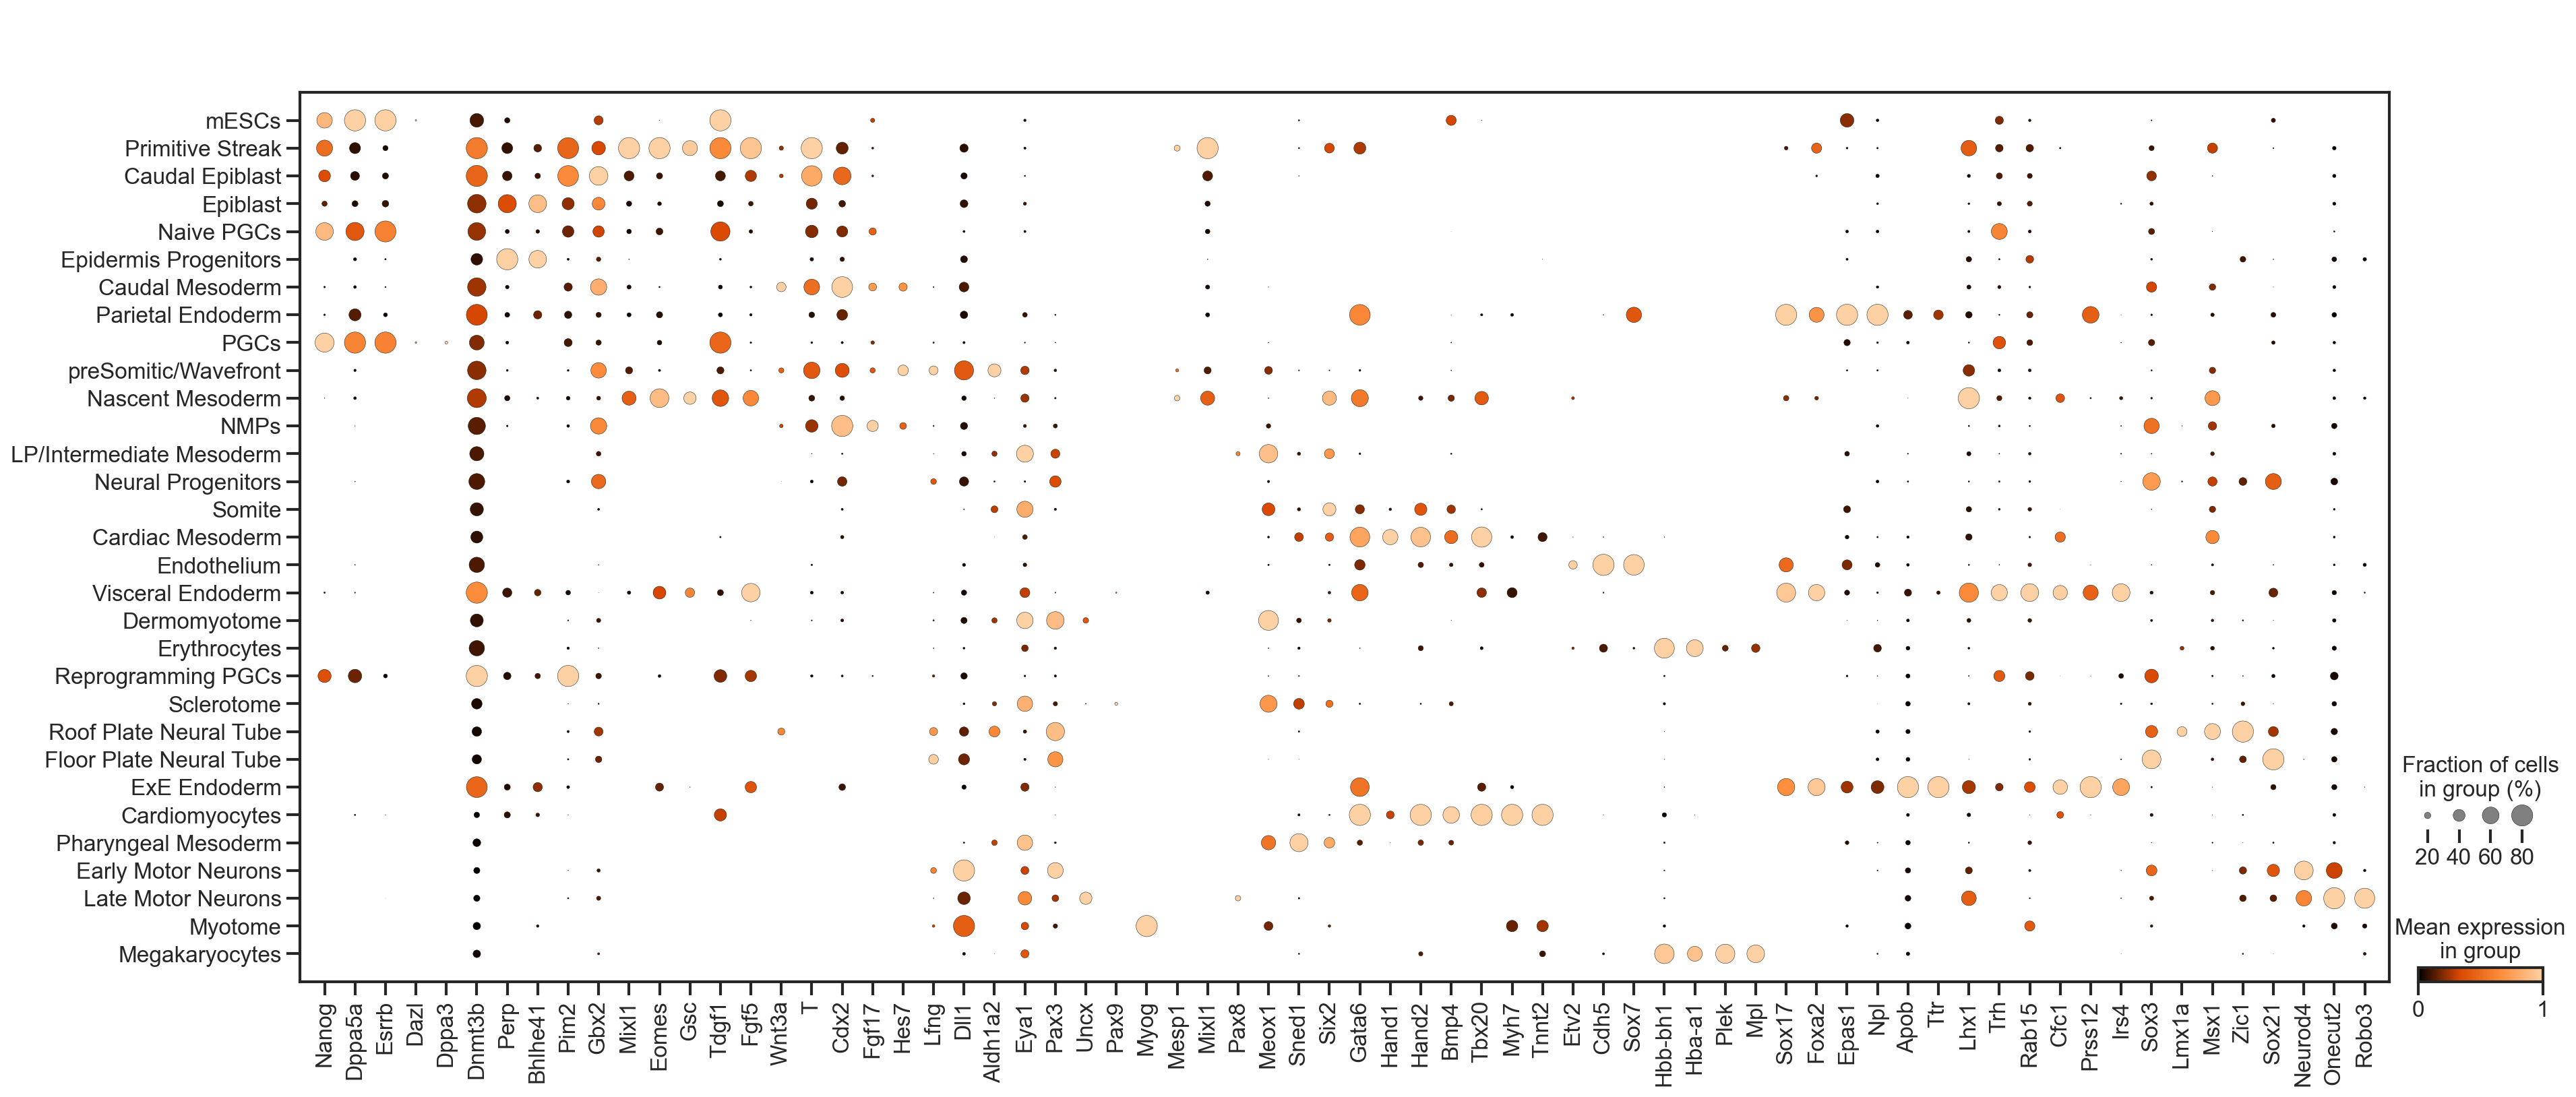

In [67]:
sns.set_style('white')
sns.set_context('talk')
sns.set_style('ticks')


genes = [
    'Nanog','Dppa5a','Esrrb',                # PGCs
    'Dazl','Dppa3',       # Mature PGCs
    'Dnmt3b',                                # Reprogramming PGCs
    'Perp','Bhlhe41',                        # Epiblast
    'Pim2','Gbx2',                     # Caudal epiblast
    'Mixl1','Eomes','Gsc','Tdgf1','Fgf5',    # Primitive streak
    'Wnt3a',                                 # Caudal mesoderm
    'T','Cdx2','Fgf17',                      # NMP
    'Hes7','Lfng','Dll1','Aldh1a2',          # Presomitic/Wavefront                - 'Notch1', 'Tbx6','Dll1','Snai1','Tbx6','Aldh1a2',
    'Eya1',                          # (early) somite
    'Pax3','Uncx',                           # Dermomyotome
    'Pax9',                           # Sclerotome
    'Myog',                   # Myotome
    'Mesp1','Mixl1',                        # Nascent mesoderm 
    'Pax8','Meox1','Sned1','Six2','Gata6', # Pharyngeal mesoderm
    'Hand1','Hand2', 'Bmp4','Tbx20', 'Myh7','Tnnt2', 'Etv2',                            # Hematoendothelial progenitors
    'Cdh5','Sox7', 'Hbb-bh1','Hba-a1', 'Plek','Mpl', 'Sox17','Foxa2',                    
    'Epas1','Npl', 'Apob','Ttr','Lhx1','Trh', 'Rab15',
    'Cfc1', 'Prss12','Irs4',  'Sox3','Lmx1a','Msx1','Zic1',            
    'Sox21', 'Neurod4',  'Onecut2','Robo3',       
    ]

ax = sc.pl.dotplot(adata, genes, groupby='celltype', cmap=trans,standard_scale='var',#categories_order = order,
                   log=True,dot_min=0.05 , dot_max=0.8, save='FigS2c.pdf')


# pseudotime plots

## separated by lineage

In [68]:
ecto = ['Pluripotent','Ectoderm']
endo = ['Pluripotent','Endoderm']
meso = ['Pluripotent','Mesoderm']
adata_ecto = adata[adata.obs['lineage'].isin(ecto)]
adata_endo = adata[adata.obs['lineage'].isin(endo)]
adata_meso = adata[adata.obs['lineage'].isin(meso)]



saving figure to file ./figures/scvelo_heatmap_Fig2g_ectoderm.png


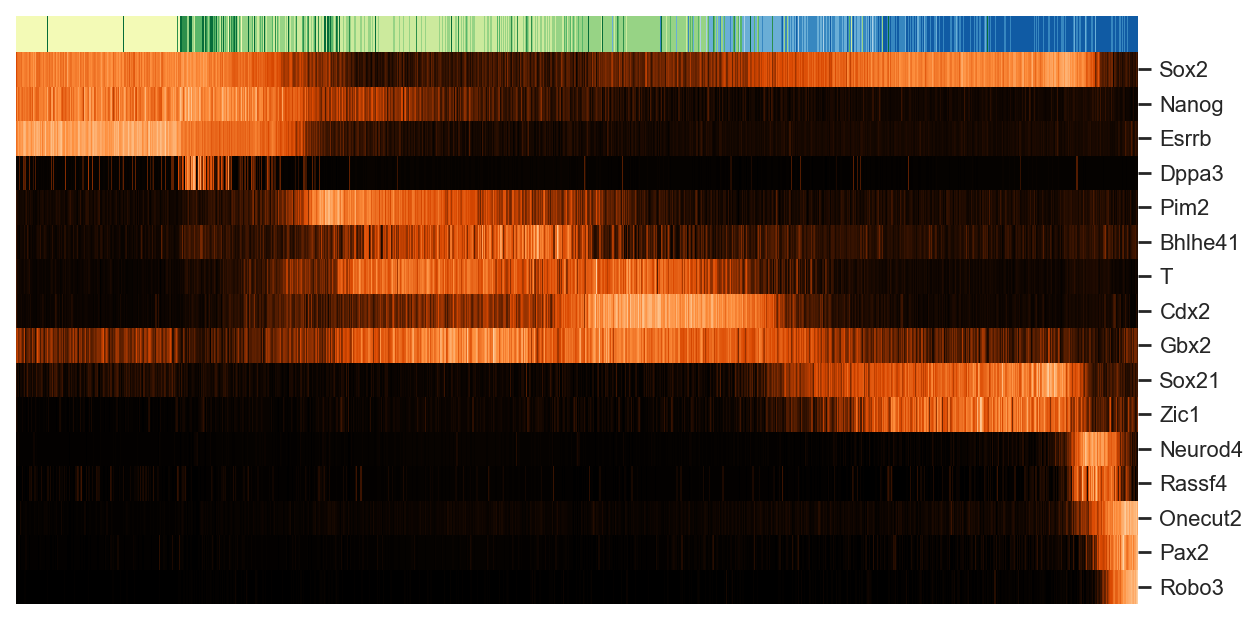

In [70]:
genes = [ 'Sox2','Nanog','Esrrb','Dppa3','Pim2',
         'Bhlhe41', 'T','Cdx2', 
         'Gbx2','Sox21','Zic1',      
         'Neurod4','Rassf4','Onecut2','Pax2','Robo3']

scv.pl.heatmap(adata_ecto,
               var_names = genes,
               sortby='PT1',
               sort = False,
               color_map = trans,
               #palette='Spectral_r',
               col_color = ['lin_day','lin_day'],
               n_convolve = 30,
               standard_scale = 0, #0 rows or 1 columns
               colorbar=True,
               #row_cluster=True,
               context = 'notebook',
               font_scale = 0.9,
             #  cbar_pos=0.2,
               figsize = (8,4),
               save = 'Fig2g_ectoderm.png'
               ) 

saving figure to file ./figures/scvelo_heatmap_Fig2g_mesoderm.png


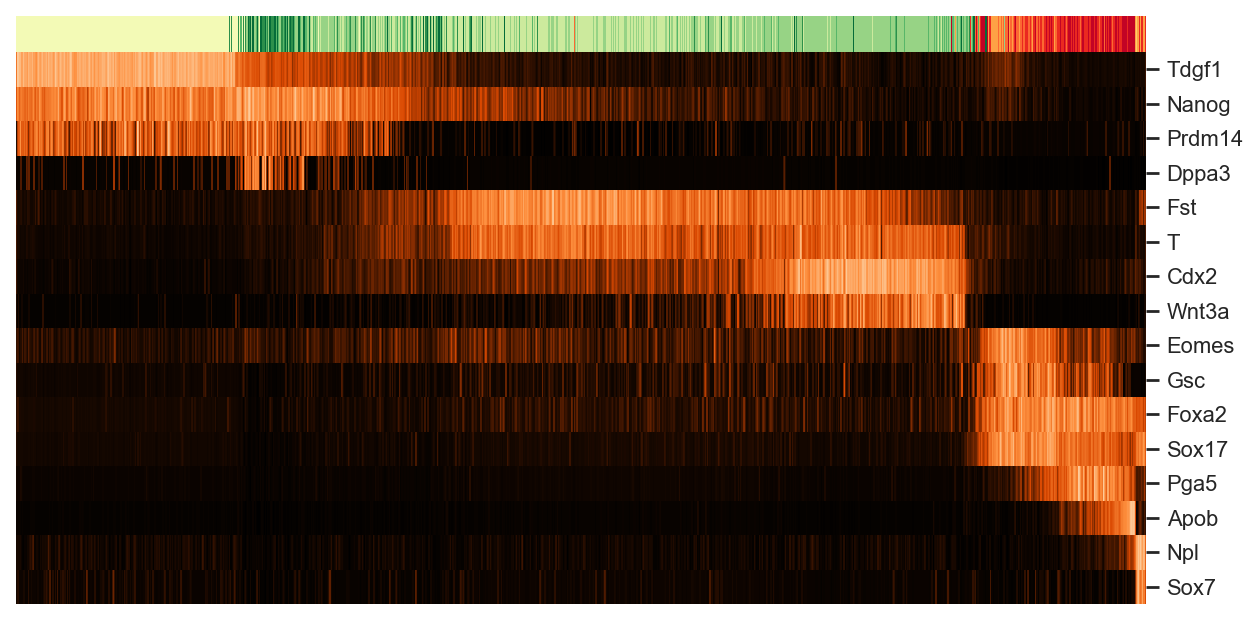

In [71]:
genes= ['Tdgf1','Nanog','Prdm14','Dppa3','Fst', #5 
        'T','Cdx2','Wnt3a', #3
        'Eomes','Gsc','Foxa2', #3
        'Sox17','Pga5','Apob','Npl','Sox7'] #5 #Gata6 Irs4
        

scv.pl.heatmap(adata_endo, var_names = genes,sortby='PT1',
               sort = False,color_map = trans, col_color = ['lin_day','lin_day'],
               n_convolve = 30,standard_scale = 0, #0 rows or 1 columns
               colorbar=True,
               #row_cluster=True,
               context = 'notebook',font_scale = 0.9, figsize = (8,4),
               save = 'Fig2g_mesoderm.png'
               ) 

saving figure to file ./figures/scvelo_heatmap_Fig2g_endoderm.png


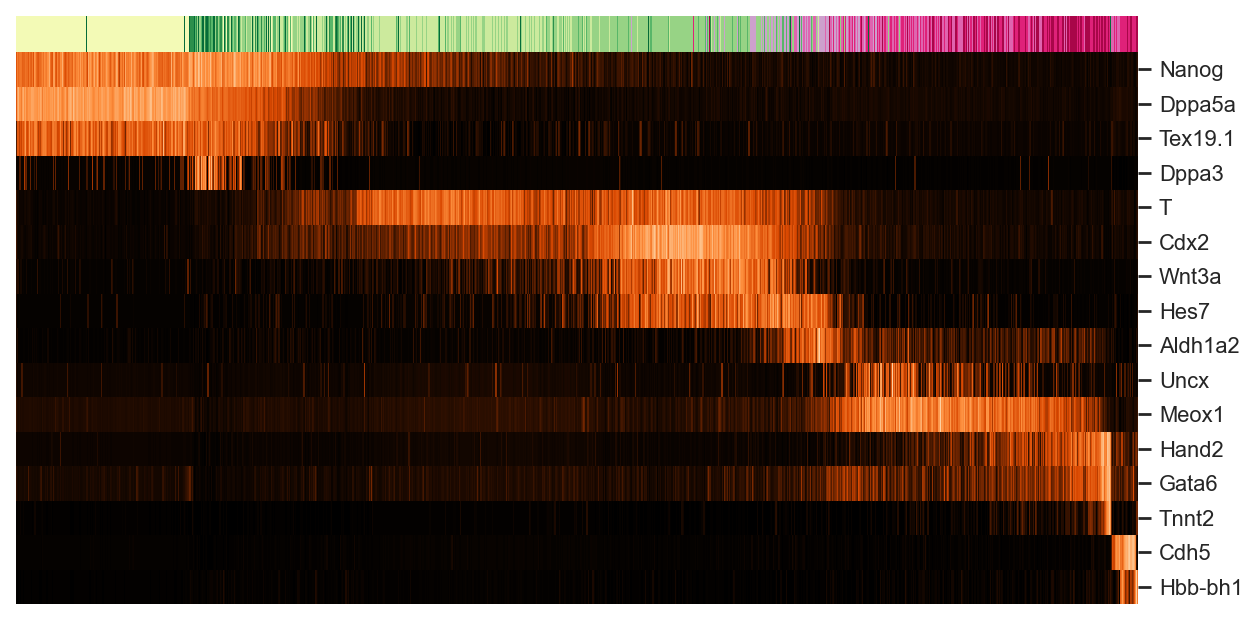

In [72]:
# 5, 3,3, 5
genes = [
    'Nanog','Dppa5a','Tex19.1','Dppa3', #5 - 4
    'T','Cdx2', 'Wnt3a',  #3
    'Hes7','Aldh1a2','Uncx', #3
    'Meox1','Hand2','Gata6','Tnnt2','Cdh5','Hbb-bh1'] #5 - 6

scv.pl.heatmap(adata_meso,var_names = genes,sortby='PT1',
               sort = False,
               color_map = trans, col_color = ['lin_day','lin_day'],
               n_convolve = 30, standard_scale = 0, #0 rows or 1 columns
               colorbar=True,
               #row_cluster=True,
               context = 'notebook',font_scale = 0.9,
               figsize = (8,4),
               save = 'Fig2g_endoderm.png'
               ) 

saving figure to file figures\umapFig2g_pseudotime_umap_ectoderm.png


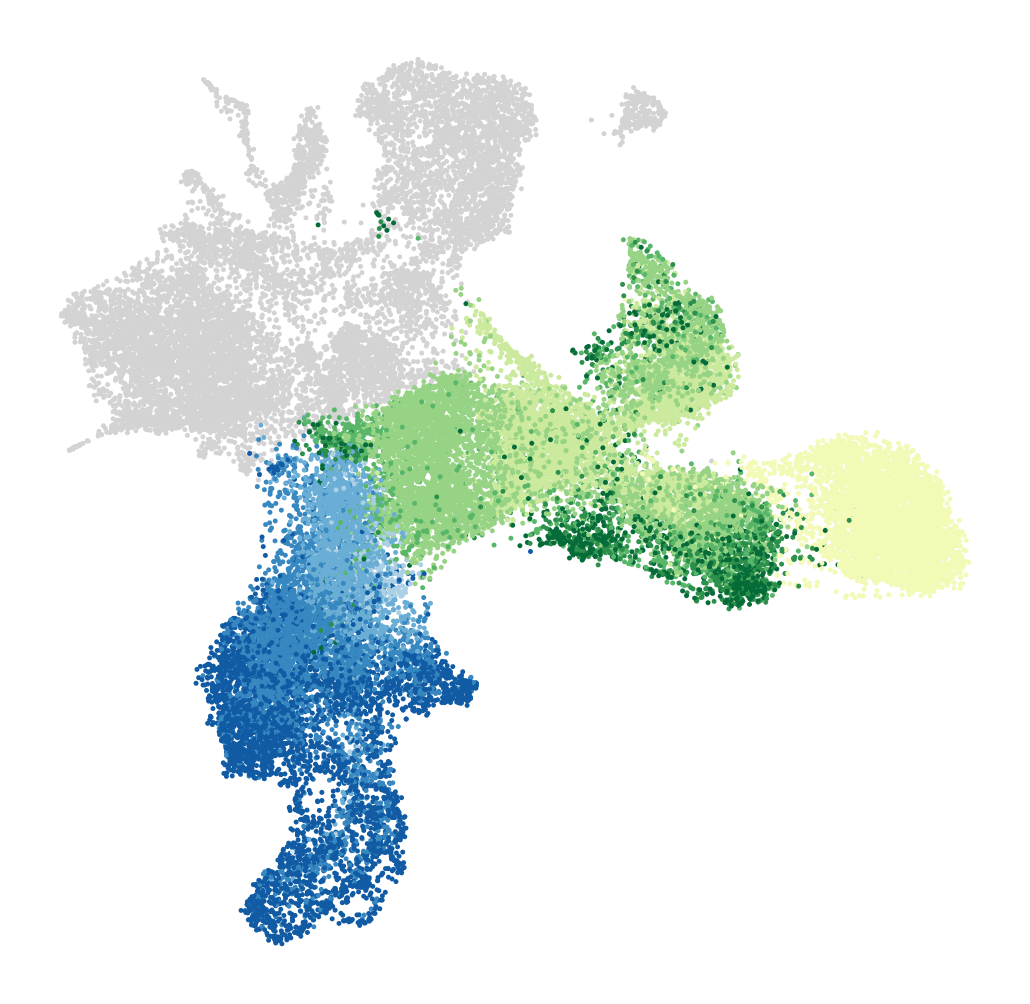

In [73]:
groups_ecto = ['Ectoderm Gastd3', 'Ectoderm Gastd4', 'Ectoderm Gastd5', 'Ectoderm Gastd6', 'Ectoderm Gastd7',
         'Pluripotent mESCs', 'Pluripotent Gastd3', 'Pluripotent Gastd4', 'Pluripotent Gastd5', 'Pluripotent Gastd6',  'Pluripotent Gastd7']

fig,ax = plt.subplots(figsize=(8,8))
sc.pl.umap(adata,color='lin_day',ax=ax,frameon=False, size = 20, legend_loc = None,
           groups = groups_ecto,title='', save ='Fig2g_pseudotime_umap_ectoderm.png')


saving figure to file figures\umapFig2g_pseudotime_umap_endoderm.png


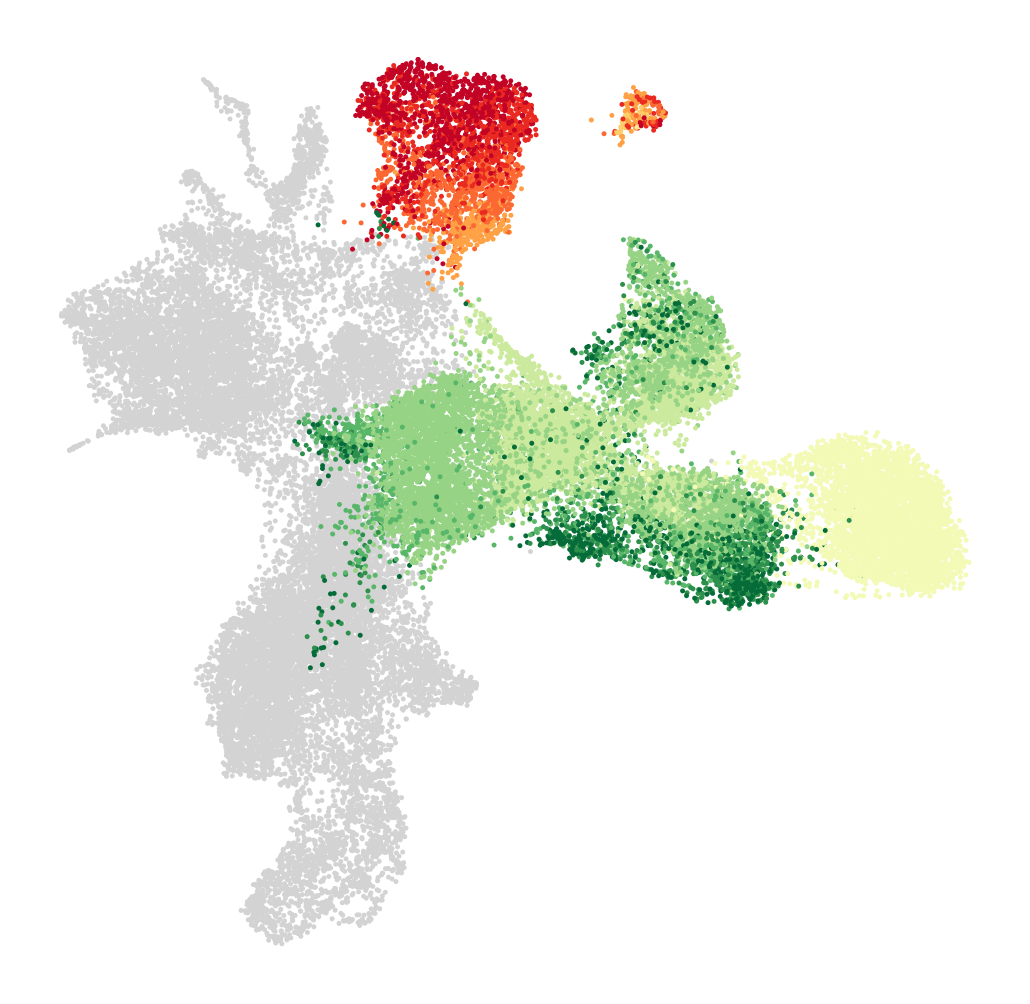

In [74]:
groups_endo = ['Endoderm mESCs', 'Endoderm Gastd3', 'Endoderm Gastd4', 'Endoderm Gastd5', 'Endoderm Gastd6', 'Endoderm Gastd7',
         'Pluripotent mESCs', 'Pluripotent Gastd3', 'Pluripotent Gastd4', 'Pluripotent Gastd5', 'Pluripotent Gastd6',  'Pluripotent Gastd7']

fig,ax = plt.subplots(figsize=(8,8))
sc.pl.umap(adata,color='lin_day',ax=ax,frameon=False, size = 20, legend_loc = None,
           groups = groups_endo,title='', save = 'Fig2g_pseudotime_umap_endoderm.png')


saving figure to file figures\umapFig2g_pseudotime_umap_mesoderm.png


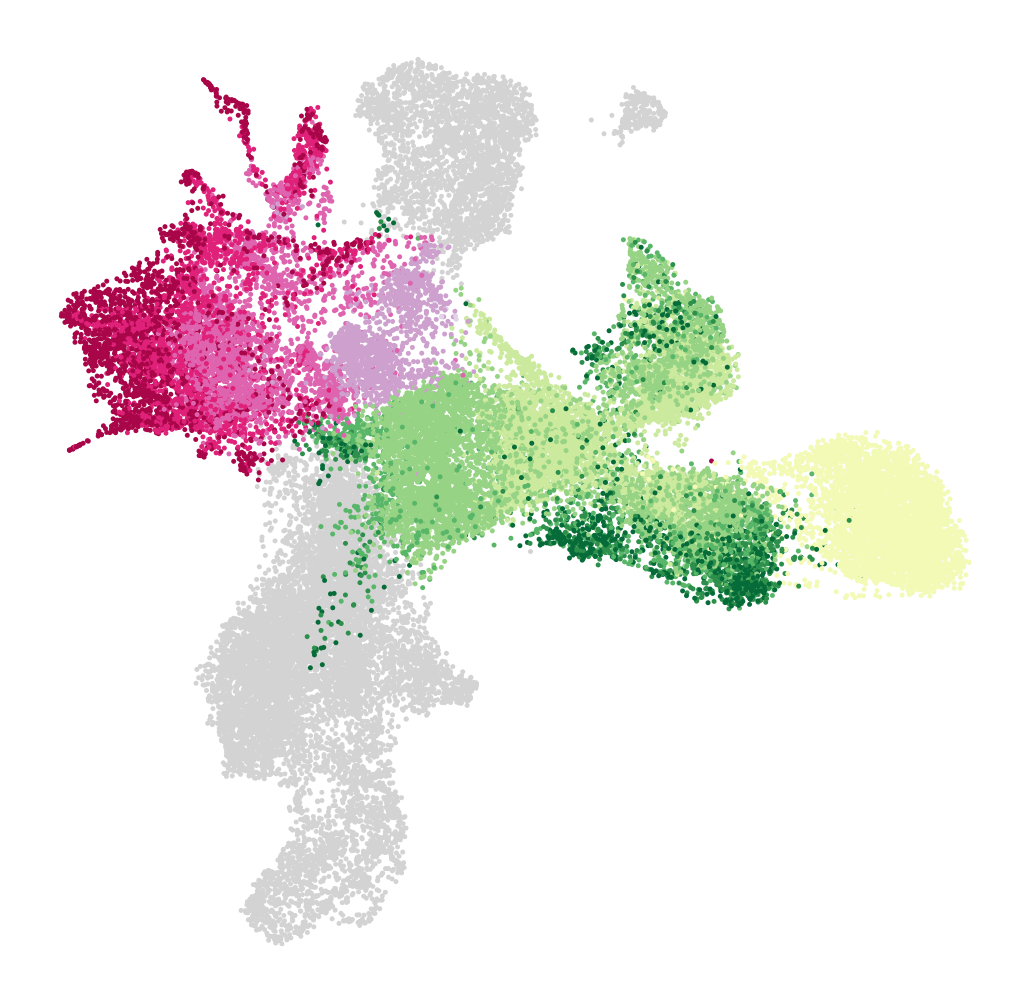

In [75]:
groups_meso = ['Mesoderm Gastd3', 'Mesoderm Gastd4', 'Mesoderm Gastd5', 'Mesoderm Gastd6', 'Mesoderm Gastd7',
         'Pluripotent mESCs', 'Pluripotent Gastd3', 'Pluripotent Gastd4', 'Pluripotent Gastd5', 'Pluripotent Gastd6',  'Pluripotent Gastd7']

fig,ax = plt.subplots(figsize=(8,8))
sc.pl.umap(adata,color='lin_day',ax=ax,frameon=False, size = 20, legend_loc = None,
           groups = groups_meso,title='', save = 'Fig2g_pseudotime_umap_mesoderm.png')
